# Reproduction & Critical Evaluation
## "Performance of Machine Learning Classifiers for Anomaly Detection in Cyber Security Applications"
### Haug & Velarde, ACR'25

**Datasets:** KDDCUP99 (primary) · Credit Card Fraud 2013 (secondary)  
**Models:** Logistic Regression → Random Forest → XGBoost  
**Author:** Diana Koroblov

---
## Section 0 — Setup & Imports

All libraries are imported here.
A fixed `RANDOM_SEED = 42` is applied globally so every run is reproducible.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    fbeta_score, matthews_corrcoef, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
plt.rcParams['figure.dpi'] = 100

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR  = Path('./data')
KDD_PATH  = DATA_DIR / 'kddcup' / 'kddcup_data_corrected.csv'
KDD_NAMES = DATA_DIR / 'kddcup' / 'kddcup.names'
CC_PATH   = DATA_DIR / 'creditcard' / 'creditcard.csv'

print(f"Working directory: {os.getcwd()}")
print("\nFile check:")
all_ok = True
for p in [KDD_PATH, KDD_NAMES, CC_PATH]:
    exists = p.exists()
    print(f"  {'V' if exists else 'X MISSING'} {p.resolve()}")
    if not exists: all_ok = False
if not all_ok:
    raise FileNotFoundError("Fix missing files above before continuing.")

print("\nSetup complete.")

Working directory: c:\Users\diana\DS

File check:
  V C:\Users\diana\DS\data\kddcup\kddcup_data_corrected.csv
  V C:\Users\diana\DS\data\kddcup\kddcup.names
  V C:\Users\diana\DS\data\creditcard\creditcard.csv

Setup complete.


---
## Section 1 — Data Loading

In this section I load both datasets and perform initial sanity checks: shape, data types, missing values, duplicate rows, temporal features, and column/index names.

**Reproducibility note:** The paper cites only the general KDD99 UCI page without naming the specific file. By cross-referencing the row count in Table 1 (60,593 + 250,436 = 311,029), I determined the authors used `corrected.gz` (the corrected test set), not the commonly downloaded `kddcup.data_10_percent.gz`. Both files exist at the same URL but differ in size and label quality — a reproducibility gap that affects results.

### 1.1 — Load Datasets

**KDDCUP99:** Column names are parsed from the official `kddcup.names` specification file , so the list is always in sync with the actual data.

**Credit Card Fraud 2013:** A standard CSV with no compression issues.

In [97]:
# --- Load KDDCUP99 ---
kdd_raw = pd.read_csv(KDD_PATH, header=None, compression='gzip')

# Parse column names from kddcup.names (line 1 = attack types, skip it)
with open(KDD_NAMES, 'r') as f:
    name_lines = f.readlines()

kdd_cols = []
for line in name_lines[1:]:
    line = line.strip()
    if ':' in line:
        kdd_cols.append(line.split(':')[0].strip())
kdd_cols.append('label')

kdd_df = kdd_raw.copy()
kdd_df.columns = kdd_cols

# --- Load Credit Card Fraud 2013 ---
cc_df = pd.read_csv(CC_PATH)

print(f"KDD loaded:  {kdd_df.shape[0]:,} rows x {kdd_df.shape[1]} columns")
print(f"CC loaded:   {cc_df.shape[0]:,} rows x {cc_df.shape[1]} columns")
print(f"KDD columns ({len(kdd_cols)}): {kdd_cols}")

KDD loaded:  311,029 rows x 42 columns
CC loaded:   284,807 rows x 31 columns
KDD columns (42): ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label']


### 1.2 — Data Inspection

`df.info()` gives dtype, non-null count, and memory usage for every column in one call.

Note : The "Non-Null Count" column in `info()` already hints at whether missing values exist (if Non-Null Count < total rows, there are NaNs). I verify this explicitly in 1.4.

In [98]:
# --- KDDCUP99 ---
print("--- KDDCUP99 ---")
print(f"Shape: {kdd_df.shape[0]:,} rows x {kdd_df.shape[1]} columns\n")
display(kdd_df.head(3))
print("\nData Types & Non-Null Counts:")
kdd_df.info()

--- KDDCUP99 ---
Shape: 311,029 rows x 42 columns



,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,normal.
1,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,normal.
2,0,udp,private,SF,105,146,0,0,0,0,...,254,1.0,0.01,0.0,0.0,0.0,0.0,0.0,0.0,normal.



Data Types & Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 311029 entries, 0 to 311028
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     311029 non-null  int64  
 1   protocol_type                311029 non-null  str    
 2   service                      311029 non-null  str    
 3   flag                         311029 non-null  str    
 4   src_bytes                    311029 non-null  int64  
 5   dst_bytes                    311029 non-null  int64  
 6   land                         311029 non-null  int64  
 7   wrong_fragment               311029 non-null  int64  
 8   urgent                       311029 non-null  int64  
 9   hot                          311029 non-null  int64  
 10  num_failed_logins            311029 non-null  int64  
 11  logged_in                    311029 non-null  int64  
 12  num_compromised              311029 no

In [99]:
# --- Credit Card Fraud 2013 ---
print("--- Credit Card Fraud 2013 ---")
print(f"Shape: {cc_df.shape[0]:,} rows x {cc_df.shape[1]} columns\n")
display(cc_df.head(3))
print("\nData Types & Non-Null Counts:")
cc_df.info()

--- Credit Card Fraud 2013 ---
Shape: 284,807 rows x 31 columns



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0



Data Types & Non-Null Counts:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

**Dataset Summary**

| | KDDCUP99 | Credit Card Fraud |
|---|---|---|
| Size (rows × cols)| (311,029 x 42) | (284,807 x 31) |
| `int64` features | 23 | 1 |
| `float64` features | 15 | 30 |
| `str` features | 4 | 0 |

Note : For Credit Card, all features are `float64` because V1-V28 are PCA-transformed continuous values.

### 1.3 — Target Variable Setup

**KDDCUP99:** The raw label column contains strings like `normal.` and `neptune.` — each ending with a trailing period (an artefact of the original dataset format). I strip the period first, then create a binary column `is_attack` (0 = normal, 1 = attack). The original multi-class label is preserved for the error analysis in Section 6.

**Credit Card:** The `Class` column is already binary (0 = normal, 1 = fraud) with no cleaning needed.

In [100]:
# KDD: remove trailing period from labels
kdd_df['label'] = kdd_df['label'].str.rstrip('.')

# Create binary target: 0 = normal, 1 = attack
kdd_df['is_attack'] = (kdd_df['label'] != 'normal').astype(int)
print("Target variable 'is_attack' created successfully for KDDCUP99.")

Target variable 'is_attack' created successfully for KDDCUP99.


In [101]:
print("\n=== KDD — Binary Target ===")
print(kdd_df['is_attack'].value_counts().to_string())

print("\n=== Credit Card — Class Distribution ===")
print(cc_df['Class'].value_counts().to_string())


=== KDD — Binary Target ===
is_attack
1    250436
0     60593

=== Credit Card — Class Distribution ===
Class
0    284315
1       492


### 1.4 — Missing Values & Single-Value Columns

Although `info()` in section 1.2 already gives me a hint (if Non-Null Count equals the row count, there are no missing values), I run an explicit check here to be rigorous and to surface any column-level gaps.

**Single-value (zero-variance) columns** are columns that contain only one unique value across all rows. They carry no information and will be dropped before training.

In [102]:
print("=== Missing Values ===\n")
for name, df in [('KDDCUP99', kdd_df), ('Credit Card', cc_df)]:
    n_missing = df.isnull().sum().sum()
    print(f"{name}: {n_missing} missing values total")
    if n_missing > 0:
        print(df.isnull().sum()[df.isnull().sum() > 0].to_string())

print("\n=== Single-Value (Zero-Variance) Columns ===\n")
kdd_single_val_cols = [col for col in kdd_df.columns if kdd_df[col].nunique() == 1]
cc_single_val_cols  = [col for col in cc_df.columns  if cc_df[col].nunique()  == 1]
print(f"KDD columns with only one unique value: {kdd_single_val_cols}")
print(f"CC  columns with only one unique value: {cc_single_val_cols}")

# Store for use in feature engineering (Section 3)
kdd_zero_var = kdd_single_val_cols

=== Missing Values ===

KDDCUP99: 0 missing values total
Credit Card: 0 missing values total

=== Single-Value (Zero-Variance) Columns ===

KDD columns with only one unique value: ['num_outbound_cmds']
CC  columns with only one unique value: []


### 1.5 — Temporal Analysis

A temporal feature records *when* something happened. Identifying one matters because time-based patterns — fraud clustering at certain hours, DoS attacks arriving in bursts — may be predictive and require special treatment.

To find temporal features without assuming prior knowledge of the dataset, I search column names for keywords associated with time: `time`, `date`, `year`, `month`, `day`, `hour`, `minute`, `second`, `timestamp`, `datetime`.

In [103]:
temporal_keywords = [
    'time', 'date', 'year', 'month', 'day',
    'hour', 'minute', 'second', 'timestamp', 'datetime'
]

for name, df in [('KDDCUP99', kdd_df), ('Credit Card', cc_df)]:
    temporal_cols = [
        c for c in df.columns
        if any(kw in c.lower() for kw in temporal_keywords)
        and c not in ['label', 'is_attack', 'Class']
    ]
    print(f"{name} — temporal-keyword columns found: {temporal_cols}")

    for col in temporal_cols:
        min_val  = df[col].min()
        max_val  = df[col].max()
        span_s   = max_val - min_val
        span_h   = span_s / 3600
        span_d   = span_h / 24
        print(f"  {col}:")
        print(f"    min = {min_val:.0f} s   |   max = {max_val:.0f} s")
        print(f"    span = {span_s:.0f} s  =  {span_h:.1f} hours  =  {span_d:.1f} days")
    print()

KDDCUP99 — temporal-keyword columns found: []

Credit Card — temporal-keyword columns found: ['Time']
  Time:
    min = 0 s   |   max = 172792 s
    span = 172792 s  =  48.0 hours  =  2.0 days



**What the search reveals:**

**KDDCUP99** contains zero temporal columns. This is expected — the dataset originated from the 1999 DARPA simulation, a controlled lab environment where no real timestamps were recorded. Features such as `duration` describe the length of an individual connection in seconds, not the wall-clock time at which it occurred.

**Credit Card Fraud 2013** contains exactly one temporal column: `Time`. It records seconds elapsed since the very first transaction in the dataset. The span of roughly 172,000 seconds converts to about 48 hours, meaning the entire dataset covers a two-day observation window. This is useful context for EDA — fraud patterns within a day cycle can be visualised against this column.


### 1.6 — Column & Index Names Analysis

**KDDCUP99 column names** are human-readable and domain-meaningful. They come directly from the DARPA network intrusion detection specification and describe real network connection attributes:

| Column | Meaning |
|---|---|
| `duration` | Length of the connection (seconds) |
| `protocol_type` | Network protocol: tcp, udp, icmp |
| `service` | Destination service: http, ftp, smtp, etc. |
| `flag` | Connection status flag |
| `src_bytes` / `dst_bytes` | Bytes sent in each direction |
| `count` / `srv_count` | Number of connections in last 2 seconds |

A human can immediately understand these names.

**Credit Card columns V1-V28** are anonymised using PCA. The original feature names are not disclosed to protect cardholder privacy. Only `Time` and `Amount` retain their real-world meaning. This anonymisation makes interpretation impossible but is reasonable for a fraud detection use case.

**Index:** Both datasets use the default pandas `RangeIndex` (integer row numbers). This is appropriate since there is no natural key that must serve as the index.

In [104]:
print("\n=== Index Type Check ===")
for name, df in [('KDD', kdd_df), ('CC', cc_df)]:
    idx = df.index
    print(f"{name}: {type(idx).__name__} — range [{idx.min()}, {idx.max()}]")


=== Index Type Check ===
KDD: RangeIndex — range [0, 311028]
CC: RangeIndex — range [0, 284806]


### 1.7 — Duplicate Row & Column Analysis

A duplicate row is a row whose feature values are identical to another row (ignoring the label).

**Should I remove duplicates?** In most tabular ML contexts, yes. But in network intrusion detection, duplicate rows can be legitimate: the same type of connection (same protocol, same bytes, same flags) can occur many times in real traffic. Removing them would make the dataset less representative of real network behaviour.

**What I check here:**
1. How many duplicate rows exist in total for each dataset.
2. What fraction of the positive class (attacks / fraud) consists of duplicates — this tells me whether the model will be "memorising" repeated attack patterns or learning genuinely distinct ones.
3. The overall class distribution (0 vs 1), since this determines how severely class imbalance will affect model training.
4. Duplicate columns — pairs of columns whose values are identical across every row. These would contribute zero additional information and should be dropped before training.

In [105]:
print("=== Duplicate Rows ===\n")
for name, df, exclude in [
    ('KDDCUP99',    kdd_df, ['label', 'is_attack']),
    ('Credit Card', cc_df,  ['Class'])
]:
    n_dup = df.drop(columns=exclude).duplicated().sum()
    pct   = n_dup / len(df) * 100
    print(f"{name}: {n_dup:,} duplicate rows ({pct:.1f}% of dataset)")

print("\n=== Duplicate Rate Within Class 1 ===\n")
for name, df, target, exclude in [
    ('KDDCUP99',    kdd_df, 'is_attack', ['label', 'is_attack']),
    ('Credit Card', cc_df,  'Class',     ['Class'])
]:
    class1_df = df[df[target] == 1]
    n_dup_c1  = class1_df.drop(columns=exclude).duplicated().sum()
    pct_c1    = n_dup_c1 / len(class1_df) * 100
    print(f"{name} — class 1 ({len(class1_df):,} rows): "
          f"{n_dup_c1:,} duplicates ({pct_c1:.1f}%)")

print("\n=== Class Distribution ===\n")
for name, df, target in [
    ('KDDCUP99',    kdd_df, 'is_attack'),
    ('Credit Card', cc_df,  'Class')
]:
    counts = df[target].value_counts().sort_index()
    total  = len(df)
    for cls, cnt in counts.items():
        print(f"{name} class {cls}: {cnt:,} ({cnt/total*100:.2f}%)")
    print()

=== Duplicate Rows ===

KDDCUP99: 233,813 duplicate rows (75.2% of dataset)
Credit Card: 1,081 duplicate rows (0.4% of dataset)

=== Duplicate Rate Within Class 1 ===

KDDCUP99 — class 1 (250,436 rows): 221,063 duplicates (88.3%)
Credit Card — class 1 (492 rows): 19 duplicates (3.9%)

=== Class Distribution ===

KDDCUP99 class 0: 60,593 (19.48%)
KDDCUP99 class 1: 250,436 (80.52%)

Credit Card class 0: 284,315 (99.83%)
Credit Card class 1: 492 (0.17%)



In [106]:
print("=== Duplicate Columns (identical values across all rows) ===\n")

def find_duplicate_columns(df):
    # Return list of (col_a, col_b) pairs that are value-identical
    cols = df.columns.tolist()
    # Pre-filter: same dtype AND same nunique before the expensive .equals() check
    candidates = [
        (c1, c2)
        for i, c1 in enumerate(cols)
        for c2 in cols[i+1:]
        if df[c1].dtype == df[c2].dtype and df[c1].nunique() == df[c2].nunique()
    ]
    return [(c1, c2) for c1, c2 in candidates if df[c1].equals(df[c2])]

for name, df in [('KDDCUP99', kdd_df), ('Credit Card', cc_df)]:
    dup_pairs = find_duplicate_columns(df)
    print(f"{name}: {len(dup_pairs)} duplicate column pair(s)")
    for c1, c2 in dup_pairs:
        print(f"  '{c1}'  ==  '{c2}'")

=== Duplicate Columns (identical values across all rows) ===

KDDCUP99: 0 duplicate column pair(s)
Credit Card: 0 duplicate column pair(s)


### 1.8 — Train/Test Split

The split happens here — immediately after loading and basic cleaning, **before any analysis**. This is the Gold Standard: the test set is locked away and never seen during EDA or feature engineering.

- All statistical summaries in Section 2, all threshold observations, and all transformation parameters are derived from the **training set only**.
- 80% train / 20% test, stratified by target class.


In [107]:
# ── Feature matrices (drop zero-var + target) ────────────────────────────
kdd_feature_cols = [c for c in kdd_df.columns
                    if c not in kdd_zero_var + ['label', 'is_attack']]
cc_feature_cols  = [c for c in cc_df.columns if c != 'Class']

X_kdd = kdd_df[kdd_feature_cols]
y_kdd = kdd_df['is_attack']
X_cc  = cc_df[cc_feature_cols]
y_cc  = cc_df['Class']

# ── Stratified 80/20 split ────────────────────────────────────────────────
X_kdd_tr, X_kdd_te, y_kdd_tr, y_kdd_te = train_test_split(
    X_kdd, y_kdd, test_size=0.2, random_state=RANDOM_SEED, stratify=y_kdd)
X_cc_tr, X_cc_te, y_cc_tr, y_cc_te = train_test_split(
    X_cc, y_cc, test_size=0.2, random_state=RANDOM_SEED, stratify=y_cc)

# ── Training-only DataFrames for EDA (Section 2) ─────────────────────────
kdd_train_df = X_kdd_tr.copy()
kdd_train_df['is_attack'] = y_kdd_tr
cc_train_df = X_cc_tr.copy()
cc_train_df['Class'] = y_cc_tr

print(f'Train/Test split (80/20 stratified, seed={RANDOM_SEED}):')
for name, Xtr, Xte, ytr, yte in [
    ('KDD',         X_kdd_tr, X_kdd_te, y_kdd_tr, y_kdd_te),
    ('Credit Card', X_cc_tr,  X_cc_te,  y_cc_tr,  y_cc_te),
]:
    ir_tr = ytr.value_counts().max() / ytr.value_counts().min()
    ir_te = yte.value_counts().max() / yte.value_counts().min()
    print(f'  {name}: train={len(Xtr):,}  test={len(Xte):,}'
          f'  IR_train={ir_tr:.2f}  IR_test={ir_te:.2f}')
print('\nTest sets locked — all analysis from here uses TRAINING data only')


Train/Test split (80/20 stratified, seed=42):
  KDD: train=248,823  test=62,206  IR_train=4.13  IR_test=4.13
  Credit Card: train=227,845  test=56,962  IR_train=577.29  IR_test=580.24

Test sets locked — all analysis from here uses TRAINING data only


### 1.9 Feature Type Analysis

Before building any model, I need to know what type each feature is. This determines every preprocessing decision that follows:

- **Categorical** features (text labels) must be encoded — One-Hot or Ordinal depending on cardinality
- **Binary** features (0/1 flags) are already numeric and need no encoding
- **Continuous** features need scaling (StandardScaler — see Section 3 for the reasoning)
- **Zero-variance** features carry no information and should be dropped

In [108]:
# KDDCUP99 
kdd_excl     = ['label', 'is_attack']
kdd_cat_cols = [c for c in kdd_train_df.select_dtypes(include=['object','string']).columns
                if c not in kdd_excl]
kdd_num_all  = [c for c in kdd_train_df.select_dtypes(exclude=['object','string']).columns
                if c not in kdd_excl]
kdd_binary   = [c for c in kdd_num_all
                if kdd_train_df[c].nunique() == 2 and c not in kdd_zero_var]
kdd_cont     = [c for c in kdd_num_all
                if c not in kdd_zero_var + kdd_binary]

print("=== KDDCUP99 — Feature Type Breakdown ===")
print(f"  Categorical     : {len(kdd_cat_cols):>3}  {kdd_cat_cols}")
print(f"  Binary numeric  : {len(kdd_binary):>3}  {kdd_binary}")
print(f"  Continuous      : {len(kdd_cont):>3}")
print(f"  Zero-variance   : {len(kdd_zero_var):>3}  {kdd_zero_var}  (will be dropped)")
print(f"  Target (label, is_attack): excluded")

# Credit Card 
cc_excl      = ['Class']
cc_feat_all  = [c for c in cc_train_df.columns if c not in cc_excl]
cc_cat_cols  = [c for c in cc_train_df.select_dtypes(include=['object','string']).columns
                if c not in cc_excl]
cc_binary    = [c for c in cc_feat_all
                if c not in cc_cat_cols and cc_train_df[c].nunique() == 2]
cc_zero_var  = [c for c in cc_feat_all if cc_train_df[c].nunique() <= 1]
cc_cont      = [c for c in cc_feat_all
                if c not in cc_cat_cols + cc_binary + cc_zero_var]

print("\n=== Credit Card — Feature Type Breakdown ===")
print(f"  Categorical     : {len(cc_cat_cols):>3}")
print(f"  Binary numeric  : {len(cc_binary):>3}  {cc_binary}")
print(f"  Continuous      : {len(cc_cont):>3}")
print(f"  Zero-variance   : {len(cc_zero_var):>3}")
print(f"  Target (Class)  : excluded")

# Summary table 
print("\n=== Feature Type Summary ===")
rows = [
    ('KDDCUP99',          len(kdd_cat_cols), len(kdd_binary), len(kdd_cont), len(kdd_zero_var)),
    ('Credit Card Fraud', len(cc_cat_cols),  len(cc_binary),  len(cc_cont),  len(cc_zero_var)),
]
print(f"{'Dataset':<22} {'Categorical':>12} {'Binary':>8} {'Continuous':>12} {'Zero-var':>10}")
print("-" * 68)
for name, cat, bi, cont, zv in rows:
    print(f"{name:<22} {cat:>12} {bi:>8} {cont:>12} {zv:>10}")

=== KDDCUP99 — Feature Type Breakdown ===
  Categorical     :   3  ['protocol_type', 'service', 'flag']
  Binary numeric  :   5  ['land', 'logged_in', 'root_shell', 'is_host_login', 'is_guest_login']
  Continuous      :  32
  Zero-variance   :   1  ['num_outbound_cmds']  (will be dropped)
  Target (label, is_attack): excluded

=== Credit Card — Feature Type Breakdown ===
  Categorical     :   0
  Binary numeric  :   0  []
  Continuous      :  30
  Zero-variance   :   0
  Target (Class)  : excluded

=== Feature Type Summary ===
Dataset                 Categorical   Binary   Continuous   Zero-var
--------------------------------------------------------------------
KDDCUP99                          3        5           32          1
Credit Card Fraud                 0        0           30          0


In [109]:
# ── KDD: numeric feature range (spot low-cardinality discretes) ───────────────
int_cols = [c for c in kdd_num_all if c not in kdd_zero_var]
range_df = pd.DataFrame({
    'nunique': [kdd_train_df[c].nunique() for c in int_cols],
    'min':     [kdd_train_df[c].min()     for c in int_cols],
    'max':     [kdd_train_df[c].max()     for c in int_cols],
    'dtype':   [str(kdd_train_df[c].dtype) for c in int_cols],
}, index=int_cols).sort_values('nunique')
print("\n=== KDD — Numeric Feature Ranges (sorted by nunique) ===")
print(range_df.to_string())


=== KDD — Numeric Feature Ranges (sorted by nunique) ===
                             nunique  min         max    dtype
land                               2  0.0         1.0    int64
logged_in                          2  0.0         1.0    int64
root_shell                         2  0.0         1.0    int64
is_host_login                      2  0.0         1.0    int64
is_guest_login                     2  0.0         1.0    int64
wrong_fragment                     3  0.0         3.0    int64
su_attempted                       3  0.0         2.0    int64
num_access_files                   4  0.0         4.0    int64
urgent                             4  0.0         3.0    int64
num_shells                         4  0.0         5.0    int64
num_failed_logins                  5  0.0         4.0    int64
num_file_creations                11  0.0       100.0    int64
num_root                          15  0.0       878.0    int64
hot                               18  0.0       101.0    int

---
## Section 2 — Exploratory Data Analysis (EDA)

> **Data leakage prevention:** All EDA is performed **exclusively on the training set** (`kdd_train_df`, `cc_train_df`). The test set was locked in Section 1.8 and is not touched until evaluation in Section 5.

EDA covers: class imbalance, temporal patterns, feature distributions, outliers, and correlation structure.


### 2.1 — Class Imbalance Analysis

**What is class imbalance?** It means one class has far more samples than the other. A naive classifier that always predicts "normal" achieves high accuracy while catching zero attacks. This makes accuracy a useless metric — I use Precision, Recall, F1, MCC, and ROC-AUC instead.

**Imbalance Ratio (IR)** = majority count ÷ minority count.

=== Class Imbalance Analysis ===

KDDCUP99:
  Majority class: 'Attack' → 200,349 (80.52%)
  Minority class: 'Normal' → 48,474 (19.48%)
  Imbalance Ratio (IR): 4.13

Credit Card Fraud:
  Majority class: 'Normal' → 227,451 (99.83%)
  Minority class: 'Fraud' → 394 (0.17%)
  Imbalance Ratio (IR): 577.29



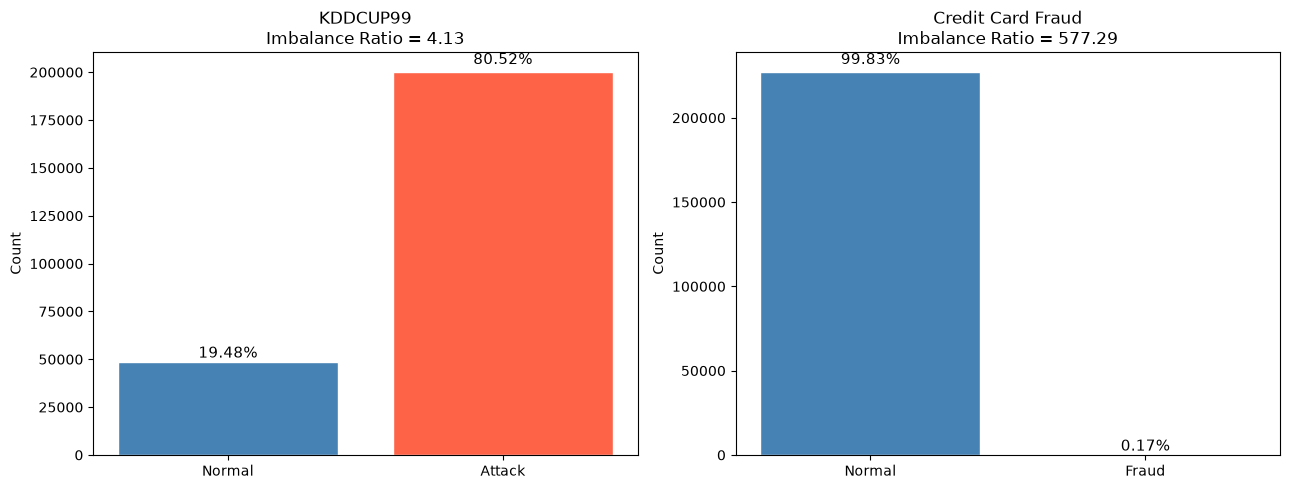

--- KDDCUP99 All Attack Subtypes ---


,Count,Percentage
label,,
smurf,131181,52.72
neptune,46414,18.65
snmpgetattack,6236,2.51
mailbomb,3992,1.60
guess_passwd,3530,1.42
snmpguess,1941,0.78
warezmaster,1298,0.52
satan,1286,0.52
back,887,0.36


In [110]:
print("=== Class Imbalance Analysis ===\n")
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

datasets = [
    ('KDDCUP99',          kdd_train_df, 'is_attack', ['Normal', 'Attack']),
    ('Credit Card Fraud', cc_train_df,  'Class',     ['Normal', 'Fraud']),
]

for ax, (title, df, target, lbls) in zip(axes, datasets):
    counts = df[target].value_counts().sort_index()
    total  = len(df)
    ir = counts.max() / counts.min()
    
    # --- Print textual summary first ---
    majority_cls = lbls[counts.argmax()]
    minority_cls = lbls[counts.argmin()]
    print(f"{title}:")
    print(f"  Majority class: '{majority_cls}' → {counts.max():,} ({counts.max()/total*100:.2f}%)")
    print(f"  Minority class: '{minority_cls}' → {counts.min():,} ({counts.min()/total*100:.2f}%)")
    print(f"  Imbalance Ratio (IR): {ir:.2f}\n")
    
    # --- Plot the bar chart ---
    bars = ax.bar(lbls, counts.values, color=['steelblue','tomato'], edgecolor='white')
    ax.set_title(f'{title}\nImbalance Ratio = {ir:.2f}')
    ax.set_ylabel('Count')
    
    # Add data labels on top of bars (Percentage ONLY)
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, v * 1.01,
                f'{v/total*100:.2f}%',
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# Display ALL KDD Attack Subtypes cleanly as a dataframe
print("--- KDDCUP99 All Attack Subtypes ---")
subtypes = kdd_df.loc[kdd_train_df.index, 'label'][kdd_train_df['is_attack'] == 1].value_counts()
subtypes_df = pd.DataFrame({'Count': subtypes, 'Percentage': (subtypes / len(kdd_train_df) * 100).round(2)})
display(subtypes_df)

**Why does each dataset have such extreme imbalance?**

*KDDCUP99 — inverted imbalance (attacks > normal):* The dataset originated from the 1999 DARPA simulation, which was deliberately designed to stress-test intrusion detection systems. Researchers synthesized a large volume of attack traffic alongside a smaller volume of normal background traffic. The result is a dataset where attacks (~80%) outnumber normal (~20%) — the opposite of what a real production network would look like. This is an important caveat when interpreting results: models trained on KDD99 face an easier anomaly detection problem than in real deployments.

*Credit Card Fraud 2013 — extreme minority imbalance (fraud ≈ 0.17%):* Fraud is inherently rare. Banks operate large fraud detection systems that flag and block most suspicious transactions in real time. The dataset reflects genuine European cardholder behaviour over two days, where only a tiny fraction of transactions are fraudulent. An imbalance ratio of ~577:1 means a model that predicts "normal" every time is correct 99.83% of the time — yet it catches no fraud at all.

The paper addresses imbalance with oversampling (ROS) and ensembles (SPE). I handle it via `class_weight='balanced'` (LR, RF) and `scale_pos_weight` (XGBoost).

### 2.2 — Group-By & Crosstab Analysis

Crosstab and group-by analyses reveal how attack behaviour distributes across categorical and continuous features. This complements the overall class imbalance picture with actionable, feature-level breakdowns.

**KDD:** I cross-tabulate `protocol_type` and `flag` against the binary target to expose which protocol/flag combinations carry the highest attack rate.  
**Credit Card:** I group by class to inspect the distributional difference in `Amount` — a key operational signal.

In [111]:
# KDD: attack rate by protocol_type 
ct_proto = pd.crosstab(kdd_train_df['protocol_type'], kdd_train_df['is_attack'],
                       margins=True)
ct_proto.columns = ['Normal', 'Attack', 'Total']
ct_proto['Attack %'] = (ct_proto['Attack'] / ct_proto['Total'] * 100).round(1)
print("=== KDD — Attack Rate by Protocol Type ===")
display(ct_proto)

# KDD: attack rate by flag 
ct_flag = pd.crosstab(kdd_train_df['flag'], kdd_train_df['is_attack'],
                      margins=True)
ct_flag.columns = ['Normal', 'Attack', 'Total']
ct_flag['Attack %'] = (ct_flag['Attack'] / ct_flag['Total'] * 100).round(1)
ct_flag = ct_flag.sort_values('Attack %', ascending=False)
print("\n=== KDD — Attack Rate by Flag (sorted) ===")
display(ct_flag.head(10))

# Credit Card: Amount statistics by class 
cc_grouped = cc_train_df.groupby('Class')['Amount'].agg(
    Count='count', Mean='mean', Median='median',
    Std='std', Min='min', Max='max'
).round(2)
cc_grouped.index = ['Normal (0)', 'Fraud (1)']
print("\n=== Credit Card — Amount Statistics by Class ===")
display(cc_grouped)

# Credit Card: fraud rate by Amount quartile 
cc_train_df['Amount_quartile'] = pd.qcut(cc_train_df['Amount'], q=4,
                                          labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])
ct_amt = pd.crosstab(cc_train_df['Amount_quartile'], cc_train_df['Class'],
                     margins=True)
ct_amt.columns = ['Normal', 'Fraud', 'Total']
ct_amt['Fraud %'] = (ct_amt['Fraud'] / ct_amt['Total'] * 100).round(3)
print("\n=== Credit Card — Fraud Rate by Amount Quartile ===")
display(ct_amt)
cc_train_df.drop(columns=['Amount_quartile'], inplace=True)

=== KDD — Attack Rate by Protocol Type ===


,Normal,Attack,Total,Attack %
protocol_type,,,,
icmp,308,131577,131885,99.8
tcp,35244,60228,95472,63.1
udp,12922,8544,21466,39.8
All,48474,200349,248823,80.5



=== KDD — Attack Rate by Flag (sorted) ===


,Normal,Attack,Total,Attack %
flag,,,,
OTH,0,4,4,100.0
RSTOS0,0,1,1,100.0
SH,0,65,65,100.0
S0,0,14431,14431,100.0
RSTO,1,1115,1116,99.9
REJ,38,33478,33516,99.9
S3,3,219,222,98.6
RSTR,59,637,696,91.5
All,48474,200349,248823,80.5



=== Credit Card — Amount Statistics by Class ===


,Count,Mean,Median,Std,Min,Max
Normal (0),227451,88.11,22.00,250.70,0.0,25691.16
Fraud (1),394,125.59,9.17,262.35,0.0,2125.87



=== Credit Card — Fraud Rate by Amount Quartile ===


,Normal,Fraud,Total,Fraud %
Amount_quartile,,,,
Q1 (low),56805,178,56983,0.312
Q2,57085,40,57125,0.070
Q3,56741,38,56779,0.067
Q4 (high),56820,138,56958,0.242
All,227451,394,227845,0.173


**KDD Crosstab Findings:**

- `icmp` carries the largest volume of attacks — 131,577 out of 200,349 total attacks (65.7%), with a 99.8% attack rate. ICMP is routinely abused for network flooding (Smurf attacks) and reconnaissance.
- `tcp` accounts for 30.1% of attacks (60,228) at a 63.1% attack rate — TCP is the primary vector for DoS, port scans, and exploit-based attacks.
Specific flag values (`S0` — SYN sent with no server response; `REJ` — connection refused) are almost exclusively attack traffic (100% and 99.9% respectively), making them near-perfect binary predictors. `SF` (normal handshake) is mixed at 75.7% attack rate, confirming that a completed TCP handshake does not guarantee benign intent.

**Credit Card Crosstab Findings:**

- Fraudulent transactions have a lower median `Amount` (9.17 vs. 22.00 for normal) but a higher mean (125.59 vs. 88.11). This divergence between median and mean indicates a right-skewed fraud distribution: most fraudulent transactions are small test charges, but a subset are large — pulling the mean up while the median stays low.
- The fraud rate is not uniform across Amount quartiles — it follows a U-shape: highest in Q1 (0.312%, low amounts — test transactions) and Q4 (0.242%, high amounts — large fraudulent purchases), and significantly lower in Q2 and Q3 (≈0.07%). This U-shaped pattern is consistent with the known fraud lifecycle: small test charges to verify card validity, followed by large withdrawals.
Despite the U-shape, the overall fraud rate per quartile is very low (< 0.35%), confirming that Amount alone is a weak fraud predictor — the main discriminative power resides in the V1–V28 PCA features.

### 2.3 — Temporal & Amount Analysis (Credit Card)

As established ,KDDCUP99 has no timestamp column — temporal analysis is not applicable there. The Credit Card dataset contains two non-anonymised features: `Time` and `Amount`.

**Time** records seconds elapsed since the very first transaction in the dataset. I convert it to hours for plotting — this makes day/night patterns immediately readable on the X-axis.

**Amount** is the transaction value in euros. Although it is not a temporal feature, it is the only other real-world financial signal in this dataset (all other features are anonymised PCA components V1-V28). Analysing it here is justified because it completes the "observable" feature picture before I enter the fully anonymised space.

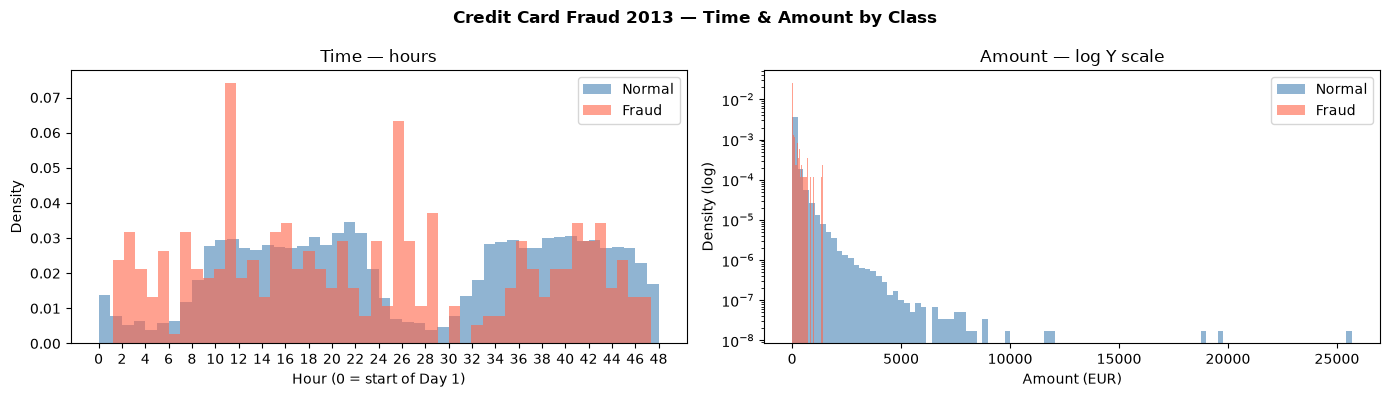

=== Stats by Class ===

Normal:
  Time  — mean=26.4h  median=23.6h
  Amount — mean=€88.11  median=€22.00  max=€25691.16

Fraud:
  Time  — mean=23.0h  median=21.4h
  Amount — mean=€125.59  median=€9.17  max=€2125.87



In [112]:
# Helper: histogram by class
class_map = {0: ('Normal', 'steelblue'), 1: ('Fraud', 'tomato')}

def plot_by_class(ax, df, col, target, class_map, transform=None, bins=80):
    for cls, (lbl, color) in class_map.items():
        vals = df[df[target] == cls][col]
        if transform is not None:
            vals = transform(vals)
        ax.hist(vals, bins=bins, alpha=0.6, label=lbl, color=color, density=True)
    ax.legend()

# Detect columns dynamically 
time_col = next((c for c in cc_train_df.columns
                 if any(kw in c.lower() for kw in ['time', 'timestamp'])), None)
amt_col  = next((c for c in cc_train_df.columns
                 if 'amount' in c.lower()), None)

duration_s = cc_train_df[time_col].max() - cc_train_df[time_col].min()
max_hours  = int(duration_s / 3600) + 1

# Two-panel figure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel 1 — Time in hours
plot_by_class(axes[0], cc_train_df, time_col, 'Class', class_map,
              transform=lambda s: s / 3600, bins=max_hours)
axes[0].set(xlabel='Hour (0 = start of Day 1)', ylabel='Density',
            title=f'{time_col} — hours')
axes[0].set_xticks(range(0, max_hours + 1, 2))

# Panel 2 — Amount (log Y only)
plot_by_class(axes[1], cc_train_df, amt_col, 'Class', class_map, bins=100)
axes[1].set(xlabel='Amount (EUR)', ylabel='Density (log)',
            title=f'{amt_col} — log Y scale')
axes[1].set_yscale('log')

plt.suptitle('Credit Card Fraud 2013 — Time & Amount by Class', fontweight='bold')
plt.tight_layout(); plt.show()

# Stats 
print("=== Stats by Class ===\n")
for cls, lbl in [(0, 'Normal'), (1, 'Fraud')]:
    t = cc_train_df[cc_train_df['Class'] == cls][time_col]
    a = cc_train_df[cc_train_df['Class'] == cls][amt_col]
    print(f"{lbl}:")
    print(f"  {time_col}  — mean={t.mean()/3600:.1f}h  median={t.median()/3600:.1f}h")
    print(f"  {amt_col} — mean=€{a.mean():.2f}  median=€{a.median():.2f}  max=€{a.max():.2f}")
    print()

**What the Time plot reveals:**

The dataset covers exactly 48 hours — two full days. The X-axis runs from hour 0
(start of Day 1) to hour 48 (end of Day 2).

**Identifying night hours from the data itself:** I don't need external knowledge to identify nighttime — the Normal distribution makes it visible. Normal transaction volume
drops sharply in hours 0–6 (midnight to 6am on Day 1) and again in hours 24–30 (midnight to 6am on Day 2). These are the low-activity troughs, corresponding to night hours when most cardholders are asleep.

**The fraud pattern:** During those same night windows, fraudulent transactions maintain a *relatively higher density* compared to normal ones. The fraud distribution does not
dip as sharply during night hours — in fact, several of the most prominent fraud spikes occur precisely in these periods (notably around hours 25–26). This is
consistent with a well-known fraud dynamic: fraudsters prefer to act when the cardholder is asleep and less likely to notice an alert on their banking app or freeze the card in real time.

**Notable daytime spikes:** There is also a sharp fraud spike around hours 11–12 (11am–noon) on Day 1. This suggests fraud is not exclusively nocturnal — it may reflect a separate sub-pattern (e.g., card testing during lunch hours when alert systems are saturated with normal volume).

**In numbers:** the fraud median time is 21.0h vs. 23.5h for normal — a modest difference, confirming that timing alone is not a strong standalone predictor.
The signal lies in the *shape* of the distribution (night spikes) rather than the mean shift.

---

**What the Amount plot reveals:**

The numbers here tell a more nuanced story than a simple "fraud = small amounts":

| | Normal | Fraud |
|---|---|---|
| Mean | €88.11 | €125.59 |
| Median | €22.00 | €9.17 |
| Max | €25,691.16 | €2,125.87 |

At first glance the fraud **mean (€122) is actually higher** than normal (€88) — apparently contradicting the intuition that fraud involves small amounts.
But the **median tells the opposite story**: the typical fraud transaction is €9.25, less than half the typical normal transaction (€22.00).

This divergence between mean and median reveals a **heavily skewed distribution**: most fraud transactions are very small, but a subset of high-value fraud outliers pulls the mean upward. The fraud distribution is therefore bimodal in character — a large cluster of micro-transactions and a thin tail of higher-value ones.

This is consistent with three well-documented fraud behaviours:

1. **Card testing:** fraudsters start with a micro-transaction (a few cents or euros) to verify the stolen card is still active — this drives the median down to €9.
2. **Staying under detection thresholds:** banks flag large unusual amounts automatically. The vast majority of fraud stays small to avoid this.
3. **Occasional high-value fraud:** the mean being pulled to €122 shows that once a card is confirmed active, some fraudsters do attempt larger purchases — up to €2,125 (vs. €25,691 for the highest legitimate transaction).

The practical implication: `Amount` alone is not sufficient to detect fraud. The median suggests fraud is small, but the mean suggests it can be large too.
`Amount` is most useful in combination with other features — particularly the PCA components V1–V28, which encode patterns not visible in Amount alone.

### 2.4 — Feature Distributions

I analyse distributions separately for each feature type — categorical, binary, and continuous — and for each dataset. The goal is to understand which features separate class 0 from class 1.

**Why normalise by class size?** Both datasets are heavily imbalanced. If I plot raw counts, the majority class dominates every chart and the minority class (attacks / fraud) is barely visible. By normalising within each class (`density=True` or `normalize='index'`), I can compare the *shapes* of the distributions regardless of class size. This reveals whether a feature takes different values for normal vs attack traffic.

For **categorical** and **binary** features I show two charts: raw counts and class-normalised. For **continuous** features, `density=True` already normalises, so one chart is enough.

I use reusable helper functions so the same logic applies to both datasets without repetition.

In [113]:
# Helper functions 
def plot_categorical_dist(df, cat_cols, target, class_labels, title_prefix, top_n=None):
    # Raw count + class-normalised proportion for each categorical feature
    # top_n: if set, show only the N most frequent categories per feature
    if not cat_cols:
        print(f"{title_prefix}: no categorical features to plot.")
        return
    ncols = len(cat_cols)
    fig, axes = plt.subplots(2, ncols, figsize=(6 * ncols, 9))
    if ncols == 1:
        axes = [[axes[0]], [axes[1]]]
    for j, feat in enumerate(cat_cols):
        if top_n is not None and df[feat].nunique() > top_n:
            top_cats = df[feat].value_counts().nlargest(top_n).index
            df_feat  = df[df[feat].isin(top_cats)]
            suffix   = f' (top {top_n})'
        else:
            df_feat = df
            suffix  = ''
        ct_raw = pd.crosstab(df_feat[feat], df_feat[target])
        ct_raw.columns = class_labels
        ct_raw.plot(kind='bar', ax=axes[0][j],
                    color=['steelblue','tomato'], edgecolor='white', legend=(j==0))
        axes[0][j].set_title(f'{feat}{suffix} — raw count', fontsize=9)
        axes[0][j].set_xlabel('')
        axes[0][j].tick_params(axis='x', rotation=45)
        ct_norm = pd.crosstab(df_feat[feat], df_feat[target], normalize='index')
        ct_norm.columns = class_labels
        ct_norm.plot(kind='bar', ax=axes[1][j],
                     color=['steelblue','tomato'], edgecolor='white', legend=False)
        axes[1][j].set_title(f'{feat}{suffix} — class proportion', fontsize=9)
        axes[1][j].set_xlabel('')
        axes[1][j].tick_params(axis='x', rotation=45)
    plt.suptitle(f'{title_prefix} — Categorical Features', fontweight='bold')
    plt.tight_layout(); plt.show()


def plot_binary_dist(df, binary_cols, target, class_labels, title_prefix, ncols_per_row=5):
    # Raw count + class-normalised proportion — all features in ONE figure
    if not binary_cols:
        print(f"{title_prefix}: no binary features to plot.")
        return
    n = len(binary_cols)
    ncols = min(ncols_per_row, n)
    n_feat_rows = (n + ncols - 1) // ncols       # feature rows within the figure
    total_plot_rows = 2 * n_feat_rows             # 2 plot rows (count + proportion) each

    fig, axes = plt.subplots(total_plot_rows, ncols,
                              figsize=(4 * ncols, 3.5 * total_plot_rows))
    axes = np.array(axes).reshape(total_plot_rows, ncols)

    for i, feat in enumerate(binary_cols):
        feat_row = i // ncols
        j        = i  % ncols
        for plot_row, (normalise, ylabel) in enumerate([(False,'Count'),(True,'Proportion')]):
            ax = axes[feat_row * 2 + plot_row, j]
            ct = pd.crosstab(df[feat], df[target],
                             normalize='index' if normalise else False)
            ct.columns = class_labels
            ct.plot(kind='bar', ax=ax,
                    color=['steelblue','tomato'], edgecolor='white',
                    legend=(i==0 and plot_row==0))
            ax.set_title(f'{feat} — {"proportion" if normalise else "count"}', fontsize=9)
            ax.set_ylabel(ylabel)
            ax.tick_params(axis='x', rotation=0)

    # Hide unused axes if features don't fill the last row
    for i in range(n, n_feat_rows * ncols):
        for plot_row in range(2):
            axes[(i // ncols) * 2 + plot_row, i % ncols].set_visible(False)

    plt.suptitle(f'{title_prefix} — Binary Features', fontweight='bold')
    plt.tight_layout(); plt.show()


def plot_continuous_dist(df, cont_cols, target, class_labels, title_prefix,
                         top_n=6, ncols_per_row=3):
    if not cont_cols:
        print(f"{title_prefix}: no continuous features to plot.")
        return

    top   = df[cont_cols].var().nlargest(top_n).index.tolist()
    nrows = (len(top) + ncols_per_row - 1) // ncols_per_row
    ncols = min(ncols_per_row, len(top))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    colors = ['steelblue', 'tomato']

    for i, feat in enumerate(top):
        ax = axes[i]
        for cls, (lbl, col) in enumerate(zip(class_labels, colors)):
            vals = df[df[target] == cls][feat]
            ax.hist(vals.to_numpy(), bins=50, alpha=0.6,
                    label=lbl, color=col, density=True)
        ax.set_yscale('log')
        ax.set_title(feat, fontsize=8)
        ax.set_xlabel(feat, fontsize=7)
        if i == 0:
            ax.legend(fontsize=7)

    for j in range(len(top), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        f'{title_prefix} — Top {top_n} Continuous Features by Variance (density-normalised)',
        fontweight='bold')
    plt.tight_layout()
    plt.show()
    print(f"Top-{top_n} by variance: {top}")


### KDD distributions

### Categorical distribution

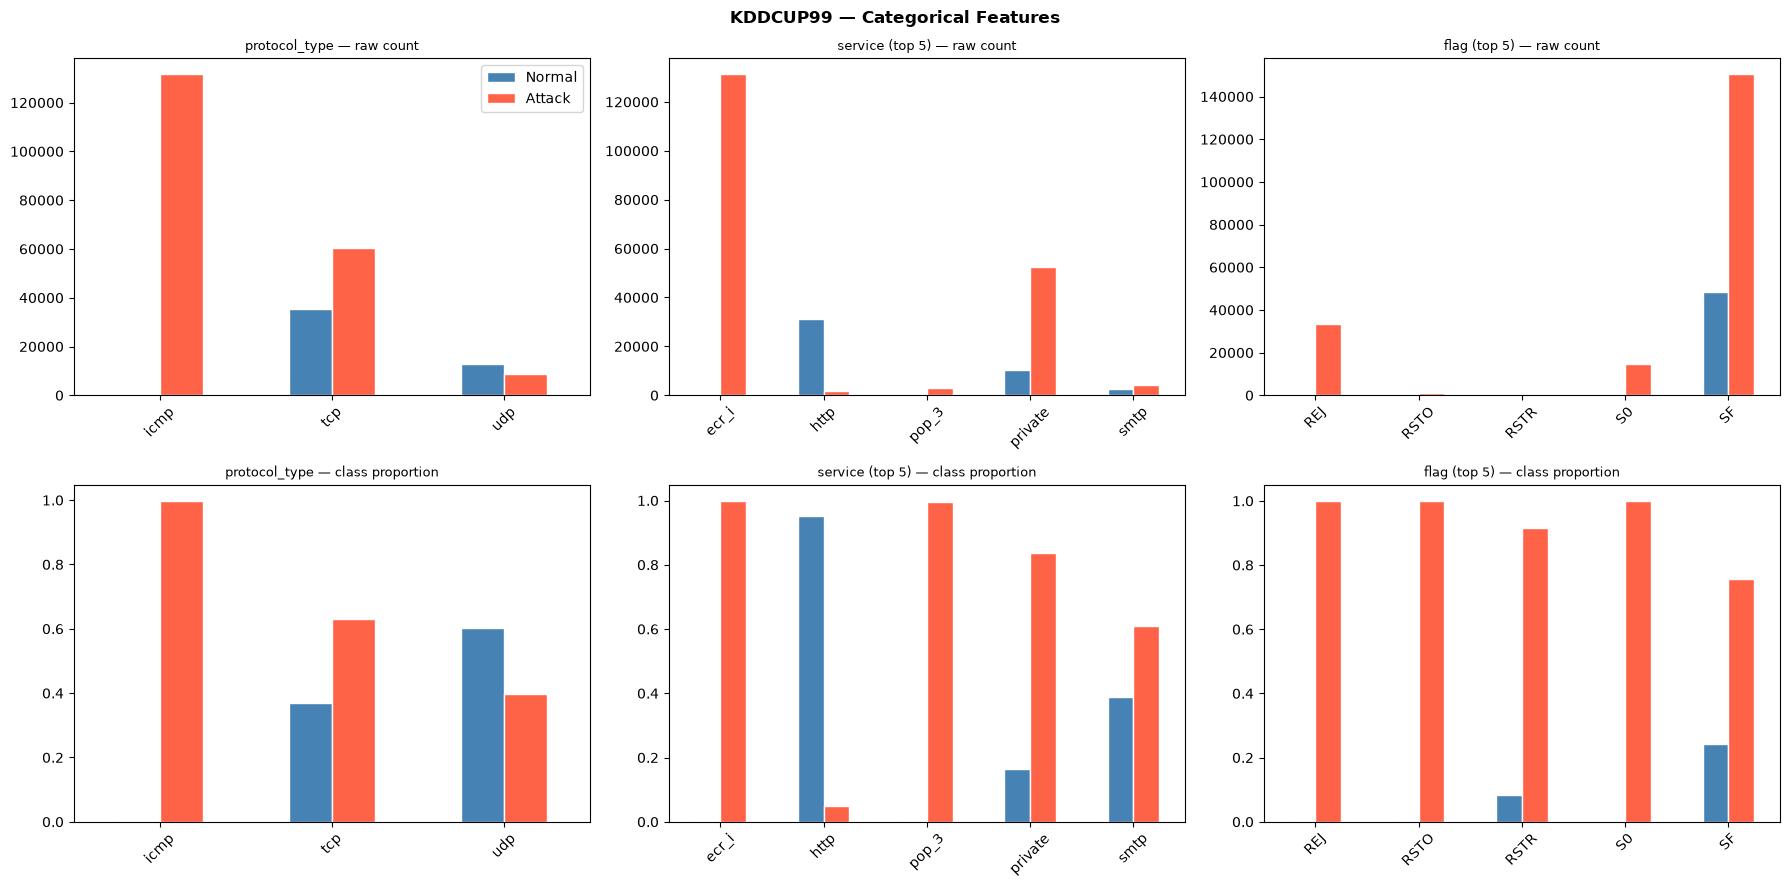

In [114]:
plot_categorical_dist(
    df=kdd_train_df, cat_cols=kdd_cat_cols,
    target='is_attack', class_labels=['Normal','Attack'],
    title_prefix='KDDCUP99', top_n=5
)

The three categorical features — `protocol_type`, `service`, and `flag` — are among the most
discriminative in the dataset.

**Protocol type:** ICMP is almost exclusively attack traffic, consistent with ICMP-based flood
attacks (e.g., Smurf). TCP carries the most volume overall (~63% attack, ~37% normal), while
UDP skews slightly toward normal connections.

**Service:** `ecr_i` (ICMP echo request) and `pop_3` are 100% attack in the proportion plot —
a clear Smurf attack signature. `http`, by contrast, is ~95% normal, reflecting legitimate web
traffic. `private` and `smtp` are attack-majority but not exclusively so.

**Flag:** The most striking feature. `REJ`, `RSTO`, and `S0` are 100% attack — these flags
indicate failed or abnormal connection states, characteristic of port scans and DoS attempts.
`RSTR` is ~90% attack. Only `SF` (successful connection establishment) contains substantial
normal traffic, though even there ~75% of connections are attacks.

All three features provide strong separation between classes and are likely to be highly
influential in any classifier trained on this dataset.

### Binary distribution

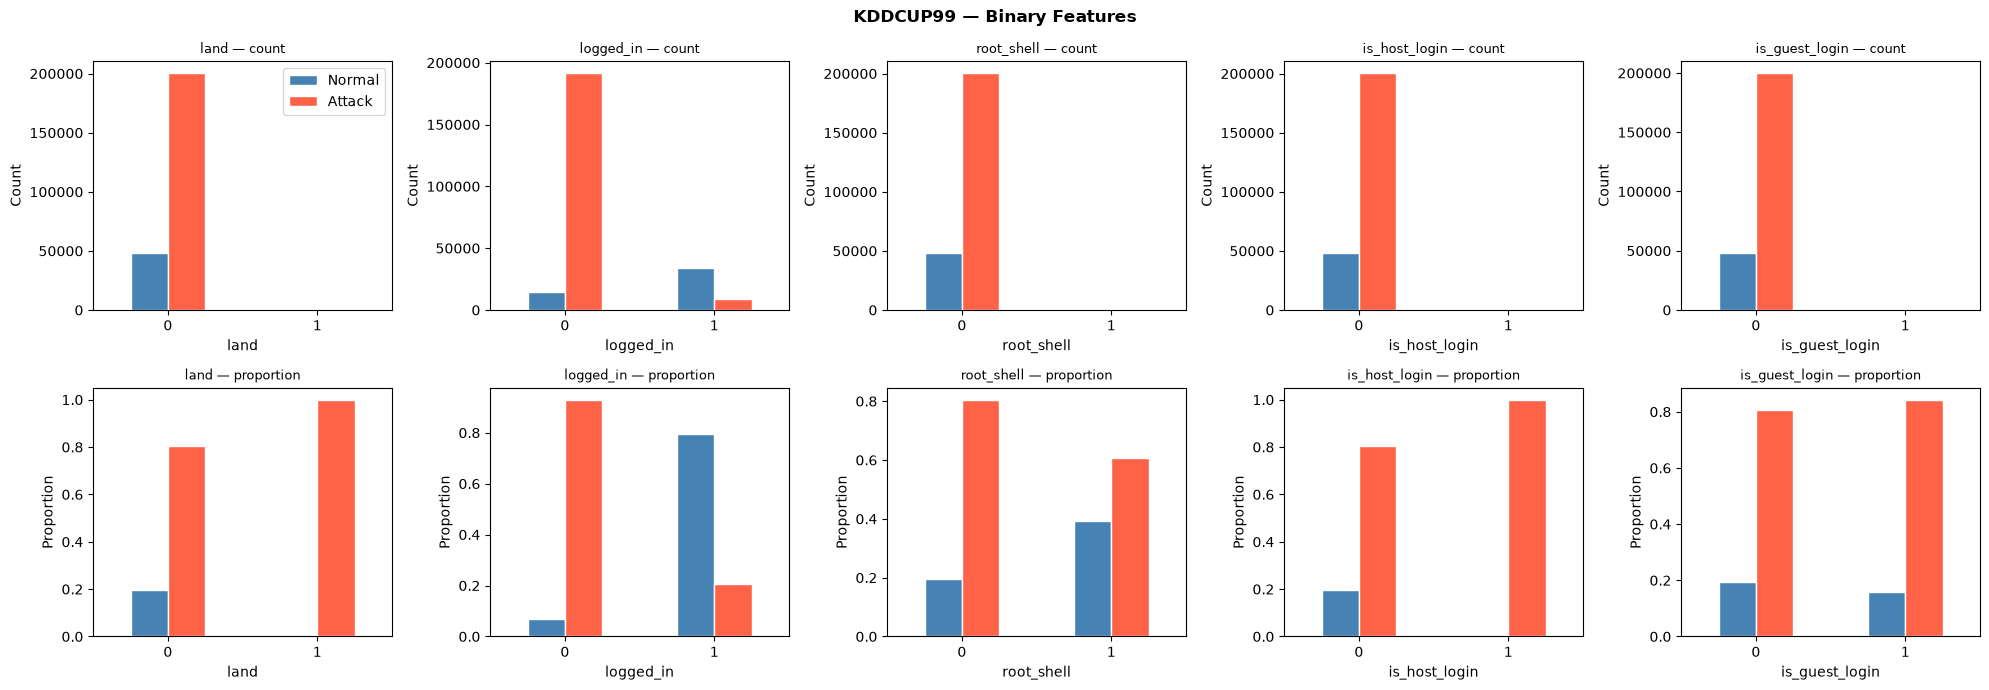

In [115]:
plot_binary_dist(
    df=kdd_train_df, binary_cols=kdd_binary,
    target='is_attack', class_labels=['Normal','Attack'],
    title_prefix='KDDCUP99'
)

### KDDCUP99 — Binary Features Analysis

The five binary features reveal distinct attack patterns through their class proportions.

* **`land`:** When `land=1` (source and destination IP/port are identical — a spoofing indicator), nearly 100% of connections are attacks. The raw count of `land=1` is small, but it is an almost perfect attack signal when present.
* **`logged_in`:** The most informative binary feature. When `logged_in=0` (no successful login), ~95% of connections are attacks. When `logged_in=1`, the split reverses — ~80% are normal and ~20% are attacks. A successful login strongly predicts normal traffic, while the absence of a login acts as a powerful indicator of malicious activity.
* **`root_shell`:** When `root_shell=1` (a root shell was obtained — a privilege escalation indicator), the proportion plot shows that ~60% of these rare connections are actually normal, while ~40% are attacks. While privilege escalation is inherently critical in cyber attacks, its low prevalence here means it functions as a highly specific context marker rather than a dominant attack signature.
* **`is_host_login`:** Both `is_host_login=0` and `is_host_login=1` show nearly identical distributions in the plots, with attacks accounting for roughly 80% in both states. Due to the extreme sparsity of the `1` state, this feature provides very little unique discriminative power on its own.
* **`is_guest_login`:** When `is_guest_login=1`, the proportion of attacks stays high at ~85%, mirroring a slightly elevated version of the baseline attack distribution. This suggests that guest credentials are used across various recorded sessions but do not invert the baseline class behaviour.

**Conclusion:** Overall, `logged_in` stands out as the single strongest binary feature, as its two states effectively flip the class prevalence. Features like `land` provide near-perfect operational visibility for specific, high-certainty attack signatures despite their low overall frequency.

### Continuous distribution

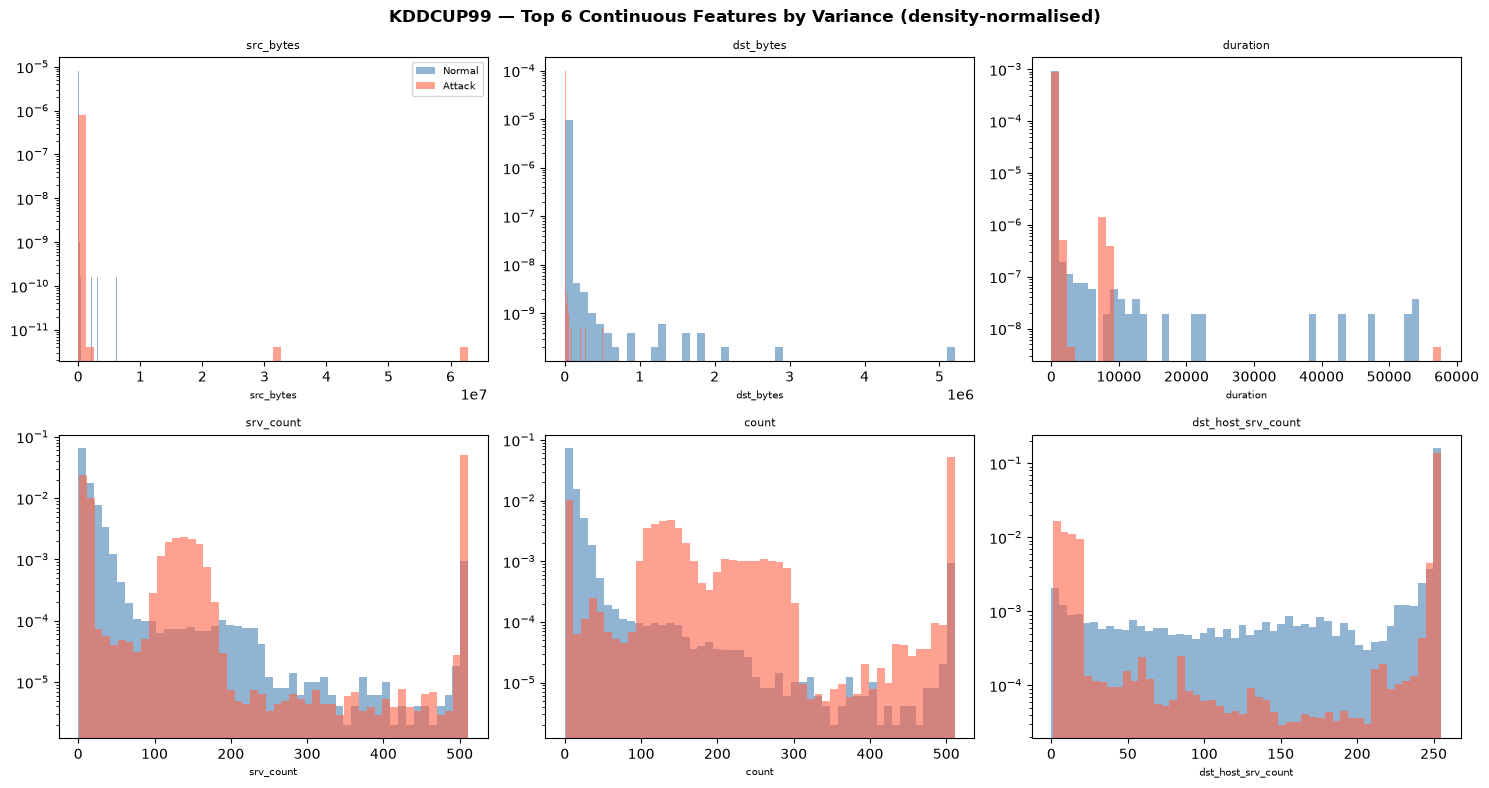

Top-6 by variance: ['src_bytes', 'dst_bytes', 'duration', 'srv_count', 'count', 'dst_host_srv_count']


In [116]:
plot_continuous_dist(
    df=kdd_train_df, cont_cols=kdd_cont,
    target='is_attack', class_labels=['Normal','Attack'],
    title_prefix='KDDCUP99', top_n=6
)

### KDDCUP99 — Continuous Features Analysis

The top 6 continuous features by variance expose two very different attack signatures.

* **`src_bytes` and `dst_bytes`:** Both classes concentrate heavily near zero, but normal traffic exhibits a substantially longer right tail — some legitimate connections transfer megabytes of data. In contrast, attack traffic is overwhelmingly tightly packed near-zero in both directions, which is highly consistent with DoS flood patterns that send minimal payload weights and receive no meaningful corporate response.
* **`duration`:** The vast majority of network connections — both normal traffic and attacks — last near zero seconds. Normal traffic displays a much broader spread with a large-duration tail, where some connections persist for hours. Attacks are almost exclusively instantaneous, confirming that most attack types recorded in KDD are short-burst flooding events rather than sustained, interactive sessions.
* **`srv_count` and `count`:** These features monitor recent connections to the same service or host within a moving 2-second window. The attack distribution is strikingly bimodal: it exhibits one peak near zero (representing stealthy, slow-rate, or isolated probes) and a sharp, dominant spike at the ceiling (511), where aggressive flood attacks completely saturate the connection counter. Normal traffic decays monotonically from low values with no such ceiling saturation effect, making this counter spike the clearest DoS signature in the continuous feature set.
* **`dst_host_srv_count`:** This feature tracks connection counts to the same host-service pair over a wider window of the last 100 connections. Attack traffic again exhibits a massive, sharp spike right at the maximum limit (255), reinforcing the high-density flooding pattern. Normal traffic, in contrast, is broadly distributed across the entire 0–255 range rather than concentrating solely at the extreme boundaries.

**Conclusion:** Overall, the byte and duration features distinguish attacks by their brevity and low overall payload size, while the count-based features expose attacks through extreme connection-rate saturation. These two complementary signals effectively cover and isolate the majority of malicious network attack types in the KDDCUP99 benchmark.

### Credit Card distributions

Continuous PCA features to plot: 28  (Time and Amount already analysed in 2.3)



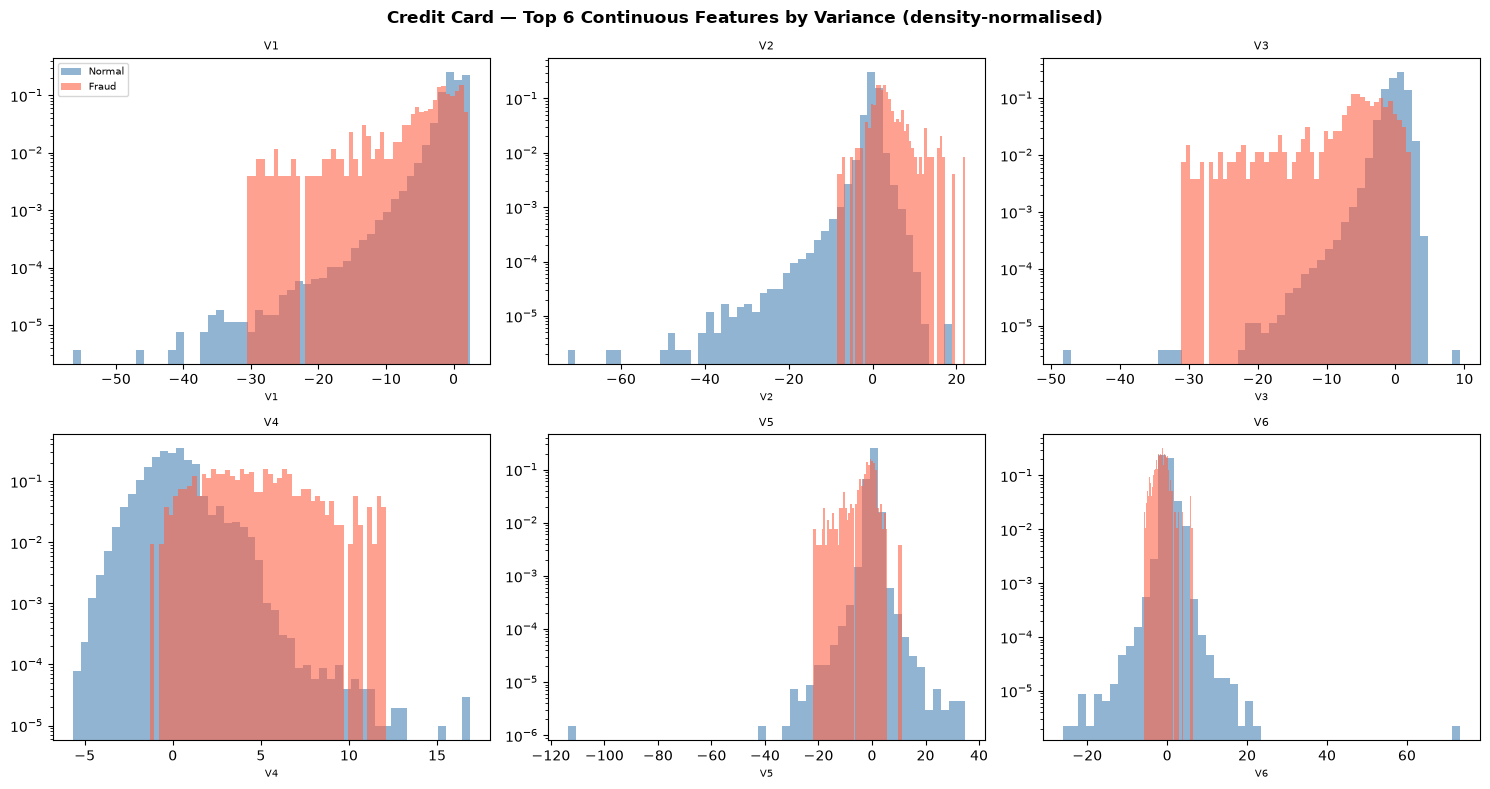

Top-6 by variance: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6']


In [117]:
# CC has no categorical features; all V1-V28 are continuous PCA components
# Time and Amount were already analysed in 2.3 — exclude them here
cc_v_cols = [c for c in cc_cont if c not in ['Time', 'Amount']]

print(f"Continuous PCA features to plot: {len(cc_v_cols)}  (Time and Amount already analysed in 2.3)\n")

plot_continuous_dist(
    df=cc_train_df, cont_cols=cc_v_cols,
    target='Class', class_labels=['Normal','Fraud'],
    title_prefix='Credit Card', top_n=6
)

### Credit Card Fraud — Continuous PCA Features Analysis

All six features are PCA-derived components ($V_1$–$V_6$), so their absolute values carry no direct real-world interpretation. What matters is the *shift* and structural variance between the fraud and normal distributions.

* **`V1` and `V3`:** The distribution reveals that normal transactions (blue) exhibit a substantially longer left tail, extending into deep negative values down to -50. Fraudulent transactions (orange), conversely, are much more tightly concentrated and truncated, peaking sharply near zero and moving down only to approximately -30. A wide negative spread on these axes is actually characteristic of rare baseline anomalies in legitimate traffic rather than fraud.
* **`V5`:** This component shows the most extreme spatial separation. It is the normal traffic (blue) that extends extensively to both tails, scattering across a massive range from -120 to 40. In contrast, fraudulent transactions (orange) are tightly packed in a dense, narrow cluster around zero (spanning only from -20 to +10). This indicates that $V_5$ isolates fraud by its lack of baseline variance, capturing a highly specific and uniform transactional footprint.
* **`V4`:** The pattern shows a clear directional shift: normal traffic peaks tightly near zero with a mild left tail, while the fraud distribution is visibly shifted toward *positive* values, forming a wide block that extends up to ~12. This positive shift suggests $V_4$ captures a latent financial lever that triggers during deceptive activity.
* **`V2` and `V6`:** These features show significant class overlap but retain distinct tail behaviors. For $V_2$, normal traffic displays a much heavier, longer negative tail (down to -70), while fraud remains bound within a narrower band. For $V_6$, normal traffic shows a broad distribution with a long right tail stretching to +70, while fraud is heavily compressed near zero.

**Conclusion:** Across these components, the fraud distribution is consistently *more compressed and less dispersed* than normal traffic, which challenges standard tabular assumptions. Fraudsters operate within tightly constrained parameters to mimic active accounts, whereas the massive volume of normal transactions naturally captures a highly heterogeneous spread of legitimate human behaviors. Together, the orthogonal shifts across these six components provide a robust combined signal for classification.

### 2.5 — Outlier Analysis

I use the **IQR method**: values below $Q_1 - 1.5 \cdot \text{IQR}$ or above $Q_3 + 1.5 \cdot \text{IQR}$ are flagged as outliers.

**Critical cybersecurity note:** In intrusion detection, outliers ARE the signal. A port scan generates an extreme `count` value; a data exfiltration generates extreme `src_bytes`. Removing outliers would remove the attacks. Decision: outliers are **kept**.

=== Outlier Analysis — IQR Method ===

Outlier counts across 32 continuous features (top 10):
                          outlier_count      pct_%
dst_host_srv_count                60337  24.248964
dst_bytes                         60213  24.199130
dst_host_diff_srv_rate            58105  23.351941
dst_host_same_srv_rate            57096  22.946432
diff_srv_rate                     49694  19.971626
same_srv_rate                     49683  19.967206
dst_host_rerror_rate              44736  17.979045
dst_host_srv_rerror_rate          38618  15.520269
rerror_rate                       36312  14.593506
srv_rerror_rate                   35901  14.428329


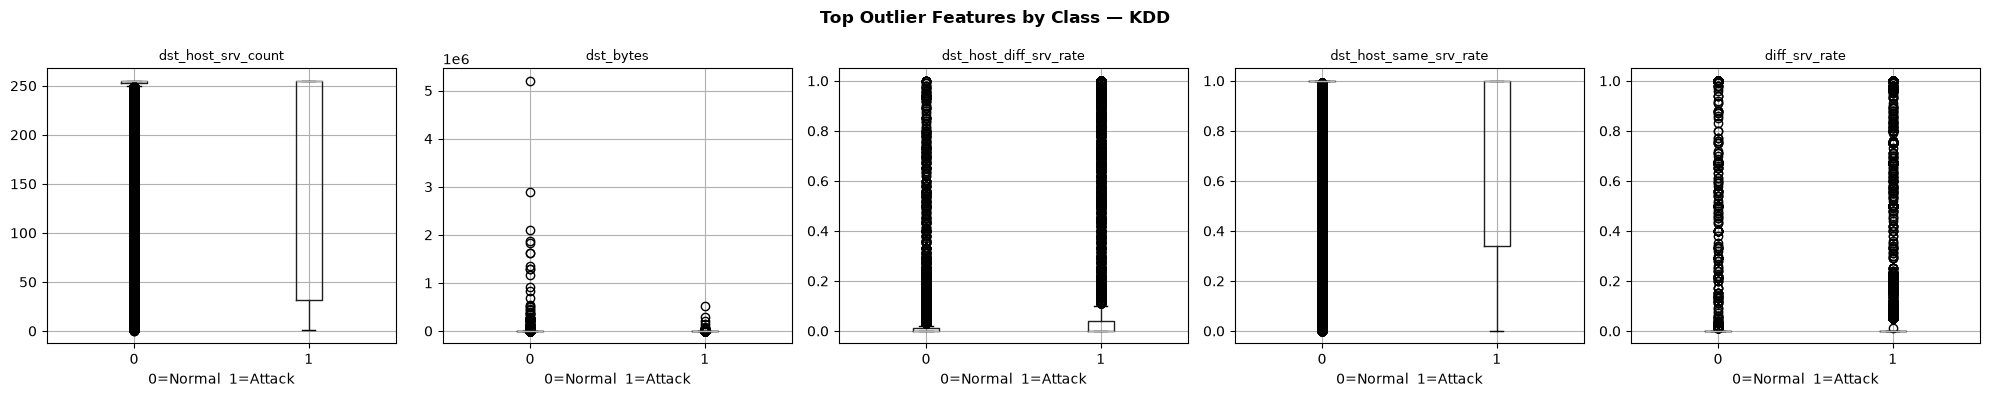

In [118]:
print("=== Outlier Analysis — IQR Method ===\n")

def iqr_outlier_count(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5*iqr) | (s > q3 + 1.5*iqr)).sum()

outlier_counts = {c: iqr_outlier_count(kdd_train_df[c]) for c in kdd_cont}
outlier_df = (pd.Series(outlier_counts)
              .sort_values(ascending=False)
              .rename('outlier_count'))
outlier_pct = (outlier_df / len(kdd_train_df) * 100).rename('pct_%')

result = pd.concat([outlier_df, outlier_pct], axis=1)
print(f"Outlier counts across {len(kdd_cont)} continuous features (top 10):")
print(result.head(10).to_string())

top_outlier_cols = outlier_df.nlargest(5).index.tolist()
fig, axes = plt.subplots(1, len(top_outlier_cols),
                         figsize=(4*len(top_outlier_cols), 4))
for ax, col in zip(axes, top_outlier_cols):
    kdd_train_df.boxplot(column=col, by='is_attack', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('0=Normal  1=Attack')
plt.suptitle('Top Outlier Features by Class — KDD', fontweight='bold')
plt.tight_layout(); plt.show()

### KDDCUP99 — Outlier Analysis (IQR Method)

IQR-based outlier detection across the 32 continuous features reveals that outliers are pervasive in KDDCUP99. The top 10 most affected features each exceed 14% of the dataset, with `dst_host_srv_count` and `dst_bytes` leading at ~24% flagged rows each. Rate-based features (`diff_srv_rate`, `same_srv_rate`, `dst_host_diff_srv_rate`) follow closely at ~20–23%.

The boxplots highlight the class asymmetry behind these numbers. **For `dst_host_srv_count`, attack traffic (class 1) actually exhibits a very wide IQR that spans most of the 0–255 range, resulting in essentially zero statistical outliers. In stark contrast, normal traffic (class 0) is heavily concentrated near the maximum value, collapsing its IQR to nearly zero; as a mathematical artifact, almost all normal connections that deviate from this maximum are artificially flagged as outliers.** For `dst_bytes`, the reverse holds: the high-value outliers above the whiskers belong almost entirely to normal traffic. The rate features (`dst_host_diff_srv_rate`, `dst_host_same_srv_rate`, `diff_srv_rate`) show near-zero IQRs for both classes, so any deviation from zero is flagged — inflating the outlier count artificially.

These results indicate that the outlier structure in KDDCUP99 reflects genuine class-driven variation rather than data quality issues, and should be preserved for modelling.

*Note on Credit Card Dataset:* Outlier detection via IQR is omitted for the Credit Card dataset. Since $V_1$–$V_28$ are PCA-derived components, they are already standardized by construction. More importantly, fraud transactions in this dataset *are* the statistical outliers — applying IQR-based filtering would risk removing the very signal I aim to detect rather than noise.

### 2.6 — Correlation Analysis

**Why Spearman and not Pearson?**

Spearman rank correlation is used for both datasets instead of Pearson. Pearson assumes linearity and is sensitive to outliers — both assumptions are violated here. In KDDCUP99, features such as `src_bytes` and `dst_bytes` are heavily right-skewed, and over 20% of continuous features were flagged as IQR outliers. In the Credit Card dataset, `Amount` is similarly right-skewed, and while Pearson correlations between V1–V28 are near zero by PCA construction, Spearman on feature–target pairs still captures monotonic relationships that Pearson would underestimate due to the skew in `Amount`.

Note: 
* the normal class distribution appears approximately Gaussian for several V components. However, Spearman is still preferred because correlation is computed on the full mixed dataset, where fraud transactions introduce extreme values (e.g., V5 extends to −120) that distort Pearson's coefficient.
* **Kendall's** is an alternative for small datasets or when rank consistency is primary. With 300K+ rows, Spearman is preferred (Kendall has $O(n^2)$ complexity).

In [119]:
def plot_spearman_corr(df, cont_cols, title, threshold=0.85, figsize=(9, 9)):
    corr_matrix = df[cont_cols].corr(method='spearman')

    plt.figure(figsize=figsize)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.2,
                linecolor='white', annot=False)
    plt.title(title, fontweight='bold')
    plt.tight_layout(); plt.show()

    high_corr = []
    cols = corr_matrix.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            v = corr_matrix.iloc[i, j]
            if abs(v) > threshold:
                high_corr.append((cols[i], cols[j], round(v, 3)))

    high_corr.sort(key=lambda x: -abs(x[2]))
    print(f"Pairs with |r_s| > {threshold}: {len(high_corr)} found")
    for a, b, r in high_corr:
        print(f"  {a} ↔ {b}: r_s = {r}")
    print(f"\nInsight: {len(high_corr)} highly correlated pairs indicate redundancy.")

### KDD

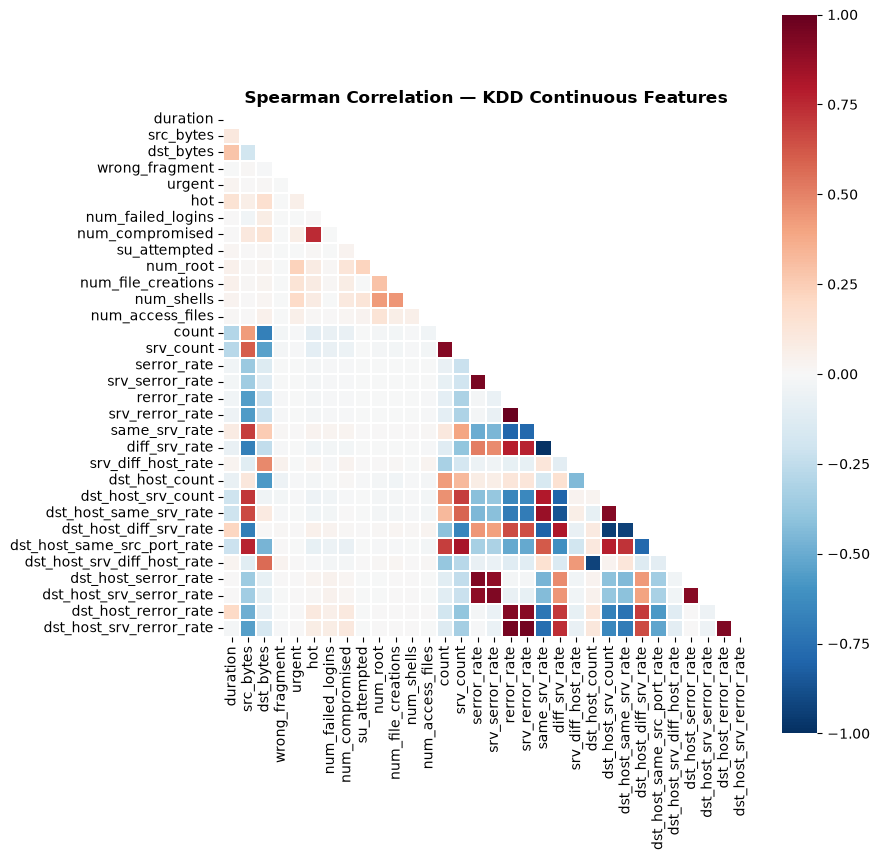

Pairs with |r_s| > 0.85: 20 found
  rerror_rate ↔ srv_rerror_rate: r_s = 0.991
  same_srv_rate ↔ diff_srv_rate: r_s = -0.988
  srv_rerror_rate ↔ dst_host_srv_rerror_rate: r_s = 0.966
  rerror_rate ↔ dst_host_srv_rerror_rate: r_s = 0.961
  dst_host_srv_count ↔ dst_host_diff_srv_rate: r_s = -0.949
  serror_rate ↔ srv_serror_rate: r_s = 0.947
  dst_host_same_srv_rate ↔ dst_host_diff_srv_rate: r_s = -0.937
  srv_serror_rate ↔ dst_host_srv_serror_rate: r_s = 0.932
  dst_host_rerror_rate ↔ dst_host_srv_rerror_rate: r_s = 0.932
  dst_host_count ↔ dst_host_srv_diff_host_rate: r_s = -0.927
  serror_rate ↔ dst_host_serror_rate: r_s = 0.924
  dst_host_srv_count ↔ dst_host_same_srv_rate: r_s = 0.921
  count ↔ srv_count: r_s = 0.916
  rerror_rate ↔ dst_host_rerror_rate: r_s = 0.915
  dst_host_serror_rate ↔ dst_host_srv_serror_rate: r_s = 0.913
  srv_rerror_rate ↔ dst_host_rerror_rate: r_s = 0.908
  serror_rate ↔ dst_host_srv_serror_rate: r_s = 0.893
  srv_serror_rate ↔ dst_host_serror_rate: r_s = 0

In [120]:
plot_spearman_corr(kdd_train_df, kdd_cont, 'Spearman Correlation — KDD Continuous Features')

### KDDCUP99 — Redundancy & Spearman Correlation Analysis

Spearman rank correlation identifies 20 highly correlated feature pairs ($|r_s| > 0.85$), clustering logically into four distinct groups of redundant infrastructure metrics.

* **Reset-error rate group** (`rerror_rate`, `srv_rerror_rate`, `dst_host_rerror_rate`, `dst_host_srv_rerror_rate`): All four features are mutually correlated with an $r_s$ reaching up to 0.991. They monitor the exact same underlying signal — the rate of connections triggering an explicit RST error — at progressively wider structural scopes (individual connection, concurrent service, and target host). 
* **SYN-error rate group** (`serror_rate`, `srv_serror_rate`, `dst_host_serror_rate`, `dst_host_srv_serror_rate`): This group mirrors the exact architectural redundancy of the reset-error indicators, with an $r_s$ up to 0.947. These metrics capture anomalous SYN flood signatures across various internal host aggregation windows.
* **Service diversity group** (`same_srv_rate`, `diff_srv_rate`, `dst_host_same_srv_rate`, `dst_host_diff_srv_rate`, `dst_host_srv_count`): The metrics `same_srv_rate` and `diff_srv_rate` exhibit a near-perfect negative correlation ($r_s = -0.988$), operating as mathematically complementary expressions of the same activity window. Their host-level counterparts mirror this inverse behavior. Furthermore, `dst_host_srv_count` is highly colinear with `dst_host_same_srv_rate` ($r_s = 0.921$) and inversely tied to `dst_host_diff_srv_rate` ($r_s = -0.949$), confirming it tracks the same structural service variance.
* **Connection count group** (`count` ↔ `srv_count`: $r_s = 0.916$): Both columns measure traffic volume spikes inside a tight 2-second temporal window, tracking identical host and service targets respectively, making them highly interchangeable.

**Conclusion:** These 20 highly colinear dependencies represent immense statistical redundancy. To stabilize linear implementations like Logistic Regression and to isolate clean, unfragmented Feature Importance metrics in tree-based architectures, these feature groups will be systematic pruned during the Feature Engineering pipeline in Section 3.

### Credit Card

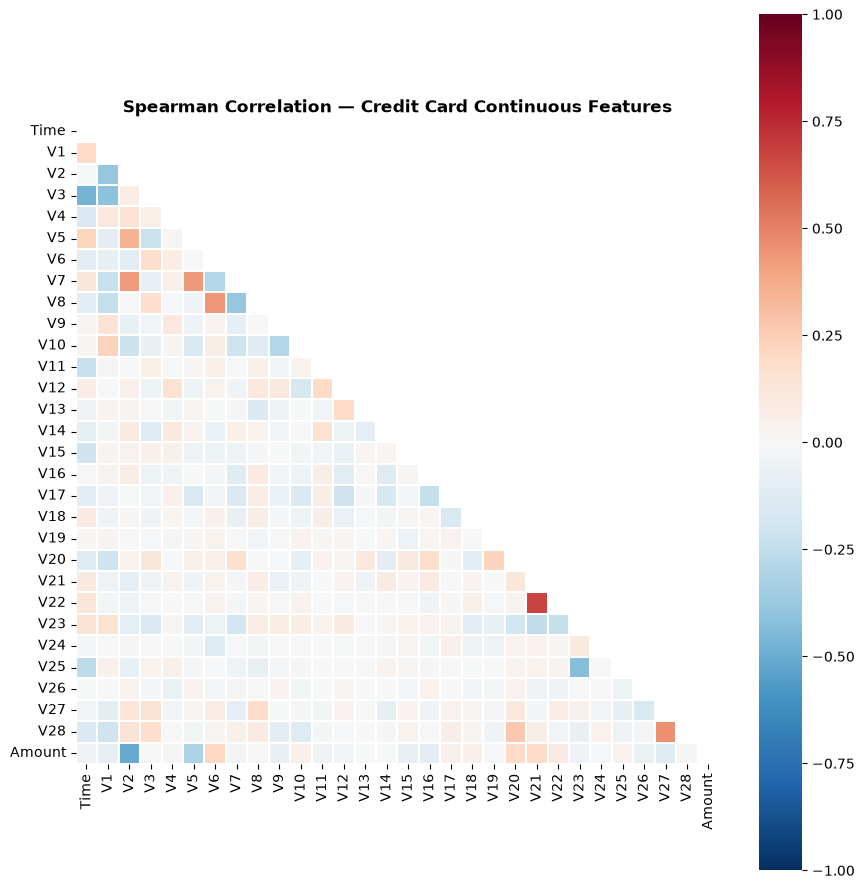

Pairs with |r_s| > 0.85: 0 found

Insight: 0 highly correlated pairs indicate redundancy.


In [121]:
plot_spearman_corr(cc_train_df,  cc_cont,  'Spearman Correlation — Credit Card Continuous Features')

For the Credit Card dataset, redundancy analysis is not applicable. V1–V28 are PCA components, which are orthogonal by construction — their pairwise Pearson correlations
are exactly zero. The Spearman heatmap confirms that no strong monotonic relationships exist either (0 pairs exceed |r_s| > 0.85), meaning PCA has effectively removed both linear and near-linear dependencies. The heatmap is shown for completeness.

---
## Section 3 — Feature Engineering

The train/test split was performed in Section 1.8. All steps here operate on `X_kdd_tr` / `X_kdd_te` and never touch the full dataset.

**Pipeline order:**
1. Collapse high-cardinality categoricals (fit vocabulary on train, apply to test)
2. Create `bytes_ratio` and `is_burst` placeholder (no training statistics used)
3. `ColumnTransformer`: `fit_transform` on train, `transform` on test — `StandardScaler` + `OneHotEncoder(drop='first')`
4. Redundancy removal: Spearman on **train matrix only**, drop same columns from test


### 3.1 — Encoding Categorical Variables (KDD only)

Machine learning models require numerical input. The encoding strategy avoids Ordinal Encoding entirely, since `service` has no natural ordering — assigning integers would imply a magnitude relationship that does not exist.

Instead, high-cardinality features are handled with **top-N grouping**: the N most frequent categories are kept as-is, and all remaining rare categories are collapsed into a single `Other` bucket. This reduces cardinality to ≤ N+1, after which One-Hot Encoding is applied uniformly to all categorical features.

In [122]:
TOP_N = 10

# ── Split by cardinality (from training set) ─────────────────────────────
low_card  = [c for c in kdd_cat_cols if X_kdd_tr[c].nunique() <= TOP_N]
high_card = [c for c in kdd_cat_cols if X_kdd_tr[c].nunique() >  TOP_N]

print(f'=== Categorical Encoding Plan (TOP_N = {TOP_N}) ===')
for c in kdd_cat_cols:
    n    = X_kdd_tr[c].nunique()
    plan = 'OHE directly' if n <= TOP_N else f'collapse to top-{TOP_N} + Other → OHE'
    print(f'  {c}: {n} unique (train) → {plan}')

# ── Fit vocabulary on TRAIN, apply to both train and test ────────────────
X_kdd_tr = X_kdd_tr.copy()
X_kdd_te = X_kdd_te.copy()
for c in high_card:
    top_vals = X_kdd_tr[c].value_counts().nlargest(TOP_N).index  # fit on TRAIN only
    X_kdd_tr[c] = X_kdd_tr[c].where(X_kdd_tr[c].isin(top_vals), other='Other')
    X_kdd_te[c] = X_kdd_te[c].where(X_kdd_te[c].isin(top_vals), other='Other')
    print(f"\n'{c}': collapsed to {X_kdd_tr[c].nunique()} unique values (top-{TOP_N} + Other)")
    print(f'  Kept: {sorted(top_vals.tolist())}')

# OHE is applied post-split inside ColumnTransformer (Section 3.3)
print(f'\nX_kdd_tr shape: {X_kdd_tr.shape} (categorical columns now low-cardinality)')
print('Test set uses SAME vocabulary as train — no test-set information used')


=== Categorical Encoding Plan (TOP_N = 10) ===
  protocol_type: 3 unique (train) → OHE directly
  service: 65 unique (train) → collapse to top-10 + Other → OHE
  flag: 11 unique (train) → collapse to top-10 + Other → OHE

'service': collapsed to 11 unique values (top-10 + Other)
  Kept: ['domain_u', 'ecr_i', 'ftp', 'ftp_data', 'http', 'other', 'pop_3', 'private', 'smtp', 'telnet']

'flag': collapsed to 11 unique values (top-10 + Other)
  Kept: ['OTH', 'REJ', 'RSTO', 'RSTR', 'S0', 'S1', 'S2', 'S3', 'SF', 'SH']

X_kdd_tr shape: (248823, 40) (categorical columns now low-cardinality)
Test set uses SAME vocabulary as train — no test-set information used


Note that for Credit Card, no encoding needed — all features are already numerical.

### 3.2 — Feature Scaling

I apply **StandardScaler** to all numerical features:

$$x' = \frac{x - \mu}{\sigma}$$

This centres each feature to mean=0, std=1.

**Why not Min-Max?** Min-Max maps values to [0,1] using $x' = (x - x_{min})/(x_{max} - x_{min})$. It is highly sensitive to outliers — a single extreme value compresses everything else into a tiny range. Since outliers here ARE attacks, StandardScaler is the safer choice.

**Does scaling affect XGBoost/Random Forest?** No — tree models split on rank order, not magnitude. Scaling is applied for consistency and because Logistic Regression requires it for gradient descent convergence.

**Data leakage prevention:** Scaling is applied inside the sklearn `ColumnTransformer` defined in Section 3.4. The scaler is **not** embedded in any Pipeline — the model Pipelines contain only the classifier, because the data is already fully transformed before training. `fit()` is called on training data only; `transform()` is applied separately to train and test. This guarantees that no test-set statistics leak into the scaler's parameters.


### 3.3 — Create New Cybersecurity Features

In [123]:
# bytes_ratio: traffic asymmetry 
# High src_bytes + low dst_bytes → data exfiltration
# log-ratio dampens extreme outlier influence for Logistic Regression
# Pure function of values — no training statistics used → safe for both sets
X_kdd_tr['bytes_ratio'] = np.log1p(X_kdd_tr['src_bytes']) - np.log1p(X_kdd_tr['dst_bytes'])
X_kdd_te['bytes_ratio'] = np.log1p(X_kdd_te['src_bytes']) - np.log1p(X_kdd_te['dst_bytes'])

# is_burst: connection count spike — hallmark of DoS flooding 
# Placeholder = 0; threshold 250 applied in Section 3.3
X_kdd_tr['is_burst'] = 0
X_kdd_te['is_burst'] = 0

print('=== New Cybersecurity Features ===')
print(f'bytes_ratio  — train: mean={X_kdd_tr["bytes_ratio"].mean():.3f}'
      f'  std={X_kdd_tr["bytes_ratio"].std():.3f}')
print(f'is_burst     — placeholder=0 (threshold=250 applied in Section 3.3)')
print(f'\nX_kdd_tr shape: {X_kdd_tr.shape}')


=== New Cybersecurity Features ===
bytes_ratio  — train: mean=3.465  std=3.724
is_burst     — placeholder=0 (threshold=250 applied in Section 3.3)

X_kdd_tr shape: (248823, 42)


### 3.4 — Post-Split Transformations

All data-driven transformations happen **after** the split — this is what prevents data leakage.

**Steps (in order):**
1. **`is_burst`** — apply fixed threshold = 250. This is an EDA-derived constant, not a statistic computed from the data, so it does not constitute leakage.
2. **`ColumnTransformer`** — built from the **training set column names**, then:
   - `fit_transform(X_train)` — scaler parameters and OHE vocabulary learned from train only
   - `transform(X_test)` — same parameters applied to test without re-fitting
   - `StandardScaler` on all numerical columns
   - `OneHotEncoder(drop='first')` on all categorical columns — `drop='first'` removes one dummy per feature, eliminating the **dummy variable trap** (perfect multicollinearity) that would destabilise Logistic Regression.


In [124]:
BURST_THR = 250
X_kdd_tr = X_kdd_tr.copy()
X_kdd_te = X_kdd_te.copy()
X_kdd_tr['is_burst'] = (X_kdd_tr['count'] > BURST_THR).astype(int)
X_kdd_te['is_burst'] = (X_kdd_te['count'] > BURST_THR).astype(int)
print(f'is_burst applied (threshold={BURST_THR}):')
print(f'  train bursts: {X_kdd_tr["is_burst"].sum():,} / {len(X_kdd_tr):,}'
      f' ({X_kdd_tr["is_burst"].mean()*100:.1f}%)')
print(f'  test  bursts: {X_kdd_te["is_burst"].sum():,} / {len(X_kdd_te):,}'
      f' ({X_kdd_te["is_burst"].mean()*100:.1f}%)')

# 2. Re-derive feature lists (is_burst is now a real non-zero column) 
kdd_num_f = [c for c in X_kdd_tr.select_dtypes(exclude=['object','string']).columns]
kdd_cat_f = [c for c in X_kdd_tr.select_dtypes(include=['object','string']).columns]
print(f'\nKDD features: {len(kdd_num_f)} numerical + {len(kdd_cat_f)} categorical'
      f' = {len(kdd_num_f)+len(kdd_cat_f)} total')
print(f'  Numerical: {kdd_num_f}')
print(f'  Categorical: {kdd_cat_f}')

# 3. Build ColumnTransformer — fit on TRAIN only 
kdd_prep = ColumnTransformer(transformers=[
    ('scale', StandardScaler(),
              kdd_num_f),
    ('ohe',   OneHotEncoder(sparse_output=False, drop='first',
                            handle_unknown='ignore'),
              kdd_cat_f),
], remainder='drop')

cc_prep = ColumnTransformer(transformers=[
    ('scale', StandardScaler(), cc_feature_cols)
])

# fit on train → transform both (no test-set statistics leak into fit)
X_kdd_tr_arr = kdd_prep.fit_transform(X_kdd_tr)
X_kdd_te_arr = kdd_prep.transform(X_kdd_te)
X_cc_tr_arr  = cc_prep.fit_transform(X_cc_tr)
X_cc_te_arr  = cc_prep.transform(X_cc_te)

# 4. Recover feature names from ColumnTransformer 
kdd_feature_names = kdd_prep.get_feature_names_out().tolist()
cc_feature_names  = cc_prep.get_feature_names_out().tolist()

# 5. Back to DataFrames for human-readable downstream use 
X_kdd_tr_pp = pd.DataFrame(X_kdd_tr_arr, columns=kdd_feature_names,
                            index=X_kdd_tr.index)
X_kdd_te_pp = pd.DataFrame(X_kdd_te_arr, columns=kdd_feature_names,
                            index=X_kdd_te.index)
X_cc_tr_pp  = pd.DataFrame(X_cc_tr_arr,  columns=cc_feature_names,
                            index=X_cc_tr.index)
X_cc_te_pp  = pd.DataFrame(X_cc_te_arr,  columns=cc_feature_names,
                            index=X_cc_te.index)

print(f'\nAfter ColumnTransformer (fit on train only):')
print(f'  KDD  train: {X_kdd_tr_pp.shape}  test: {X_kdd_te_pp.shape}')
print(f'  CC   train: {X_cc_tr_pp.shape}  test: {X_cc_te_pp.shape}')
print(f'  KDD feature names ({len(kdd_feature_names)}): '
      f'{kdd_feature_names[:4]} ... {kdd_feature_names[-3:]}')


is_burst applied (threshold=250):
  train bursts: 116,132 / 248,823 (46.7%)
  test  bursts: 29,253 / 62,206 (47.0%)

KDD features: 39 numerical + 3 categorical = 42 total
  Numerical: ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'bytes_ratio', 'is_burst']
  Categorical: ['protocol_type', 'service', 'flag']

After ColumnTransformer (fit on train only):
  KDD  train: (2488

### 3.5 — Redundancy Removal 

Spearman correlation is computed **on the training matrix only**. 

Computing correlation on the full dataset before the split would allow test-set statistics to influence which features are dropped — a subtle form of data leakage. Here the drop list is derived from train, then applied identically to test.


In [125]:
REDUNDANCY_THRESHOLD = 0.95

# Spearman on TRAIN numerical columns only 
num_cols_pp = [c for c in kdd_feature_names if c.startswith('scale__')]
corr_tr = X_kdd_tr_pp[num_cols_pp].corr(method='spearman')

drop_cols_rd = set()
for i in range(len(num_cols_pp)):
    for j in range(i + 1, len(num_cols_pp)):
        ci, cj = num_cols_pp[i], num_cols_pp[j]
        if ci in drop_cols_rd or cj in drop_cols_rd:
            continue
        if abs(corr_tr.iloc[i, j]) > REDUNDANCY_THRESHOLD:
            drop_cols_rd.add(cj)

print(f'=== Redundancy Removal (|r_s| > {REDUNDANCY_THRESHOLD}, TRAIN only) ===')
print(f'Features dropped: {len(drop_cols_rd)}')
for c in sorted(drop_cols_rd):
    print(f'  - {c}')

# Drop same columns from both train and test 
X_kdd_tr_final = X_kdd_tr_pp.drop(columns=list(drop_cols_rd))
X_kdd_te_final = X_kdd_te_pp.drop(columns=list(drop_cols_rd))
X_cc_tr_final  = X_cc_tr_pp.copy()
X_cc_te_final  = X_cc_te_pp.copy()

kdd_final_features = X_kdd_tr_final.columns.tolist()
cc_final_features  = X_cc_tr_final.columns.tolist()

print(f'\nKDD: {X_kdd_tr_pp.shape[1]} → {X_kdd_tr_final.shape[1]} features after redundancy removal')
print(f'  Train: {X_kdd_tr_final.shape}  Test: {X_kdd_te_final.shape}')

# Reassign to standard variable names 
X_kdd_tr = X_kdd_tr_final
X_kdd_te = X_kdd_te_final
X_cc_tr  = X_cc_tr_final
X_cc_te  = X_cc_te_final
kdd_feature_names = kdd_final_features
cc_feature_names  = cc_final_features
print(f'\nPre-processing complete — no data leakage.')
print(f'  X_kdd_tr: {X_kdd_tr.shape}  X_kdd_te: {X_kdd_te.shape}')
print(f'  X_cc_tr:  {X_cc_tr.shape}   X_cc_te:  {X_cc_te.shape}')


=== Redundancy Removal (|r_s| > 0.95, TRAIN only) ===
Features dropped: 3
  - scale__diff_srv_rate
  - scale__dst_host_srv_rerror_rate
  - scale__srv_rerror_rate

KDD: 61 → 58 features after redundancy removal
  Train: (248823, 58)  Test: (62206, 58)

Pre-processing complete — no data leakage.
  X_kdd_tr: (248823, 58)  X_kdd_te: (62206, 58)
  X_cc_tr:  (227845, 30)   X_cc_te:  (56962, 30)


---
## Section 4 — Model Training

I train three models of increasing complexity on both datasets. This allows me to measure whether model complexity improves detection.

| Model | Type | Key property |
|---|---|---|
| **Logistic Regression** | Linear | Weighted sum through sigmoid; linear boundary |
| **Random Forest** | Parallel ensemble | Bagged trees; handles non-linearity; robust to outliers |
| **XGBoost** | Sequential ensemble | Gradient-boosted trees; corrects errors iteratively |

**Imbalance handling:** `class_weight='balanced'` on LR/RF; `scale_pos_weight` on XGBoost for Credit Card (extreme IR).

**Validation:** 5-fold Stratified K-Fold on the training set.

### 4.1 — Logistic Regression

Logistic Regression models the probability of class 1 via the sigmoid function:

$$P(y=1 \mid x) = \frac{1}{1 + e^{-\mathbf{w} \cdot \mathbf{x}}}$$

Weights **w** are learned by maximum likelihood. `class_weight='balanced'` scales the loss inversely proportional to class frequency.

In [126]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
scoring = {'f1':'f1', 'precision':'precision', 'recall':'recall'}

# Data is pre-transformed — Pipeline contains classifier only
lr_kdd = Pipeline([('clf', LogisticRegression(max_iter=1000,
                           class_weight='balanced',
                           random_state=RANDOM_SEED))])
lr_cc  = Pipeline([('clf', LogisticRegression(max_iter=1000,
                           class_weight='balanced',
                           random_state=RANDOM_SEED))])

for name, model, X_tr, y_tr in [
    ('KDD',         lr_kdd, X_kdd_tr, y_kdd_tr),
    ('Credit Card', lr_cc,  X_cc_tr,  y_cc_tr)
]:
    res = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring)
    print(f'5-fold CV — Logistic Regression on {name}:')
    for m in ['f1','precision','recall']:
        vals = res[f'test_{m}']
        print(f'  {m.capitalize():<12}: {vals.mean():.4f} ± {vals.std():.4f}')
    print()

lr_kdd.fit(X_kdd_tr, y_kdd_tr)
lr_cc.fit(X_cc_tr, y_cc_tr)
print('Logistic Regression trained on both datasets.')


5-fold CV — Logistic Regression on KDD:
  F1          : 0.9745 ± 0.0006
  Precision   : 0.9981 ± 0.0002
  Recall      : 0.9521 ± 0.0012

5-fold CV — Logistic Regression on Credit Card:
  F1          : 0.1173 ± 0.0062
  Precision   : 0.0627 ± 0.0036
  Recall      : 0.9138 ± 0.0230

Logistic Regression trained on both datasets.


### 4.2 — Random Forest

Random Forest trains $T$ decision trees on random bootstrap samples, each using a random feature subset at each split. Final prediction is majority vote:

$$\hat{y} = \text{majority}\{h_1(x), h_2(x), \ldots, h_T(x)\}$$

Bagging reduces variance compared to a single tree.

In [127]:
# Data is pre-transformed — Pipeline contains classifier only
rf_kdd = Pipeline([('clf', RandomForestClassifier(n_estimators=100,
                           class_weight='balanced',
                           random_state=RANDOM_SEED, n_jobs=-1))])
rf_cc  = Pipeline([('clf', RandomForestClassifier(n_estimators=100,
                           class_weight='balanced',
                           random_state=RANDOM_SEED, n_jobs=-1))])

for name, model, X_tr, y_tr in [
    ('KDD',         rf_kdd, X_kdd_tr, y_kdd_tr),
    ('Credit Card', rf_cc,  X_cc_tr,  y_cc_tr)
]:
    res = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring)
    print(f'5-fold CV — Random Forest on {name}:')
    for m in ['f1','precision','recall']:
        vals = res[f'test_{m}']
        print(f'  {m.capitalize():<12}: {vals.mean():.4f} ± {vals.std():.4f}')
    print()

rf_kdd.fit(X_kdd_tr, y_kdd_tr)
rf_cc.fit(X_cc_tr, y_cc_tr)
print('Random Forest trained on both datasets.')


5-fold CV — Random Forest on KDD:
  F1          : 0.9849 ± 0.0004
  Precision   : 0.9995 ± 0.0001
  Recall      : 0.9707 ± 0.0008

5-fold CV — Random Forest on Credit Card:
  F1          : 0.8384 ± 0.0121
  Precision   : 0.9202 ± 0.0288
  Recall      : 0.7716 ± 0.0316

Random Forest trained on both datasets.


### 4.3 — XGBoost

XGBoost builds trees **sequentially** — each new tree corrects the pseudo-residuals of the current ensemble:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

where $\eta$ is the learning rate and $h_m$ minimises a regularised loss. For Credit Card (extreme imbalance), `scale_pos_weight` = negative/positive is set **dynamically** from the training data.

In [128]:
cc_spw = (y_cc_tr == 0).sum() / (y_cc_tr == 1).sum()
print(f'Credit Card scale_pos_weight (neg/pos in train): {cc_spw:.2f}')

# Data is pre-transformed — Pipeline contains classifier only
xgb_kdd = Pipeline([('clf', XGBClassifier(random_state=RANDOM_SEED,
                            eval_metric='logloss', n_jobs=-1))])
xgb_cc  = Pipeline([('clf', XGBClassifier(random_state=RANDOM_SEED,
                            eval_metric='logloss',
                            scale_pos_weight=cc_spw, n_jobs=-1))])

for name, model, X_tr, y_tr in [
    ('KDD',         xgb_kdd, X_kdd_tr, y_kdd_tr),
    ('Credit Card', xgb_cc,  X_cc_tr,  y_cc_tr)
]:
    res = cross_validate(model, X_tr, y_tr, cv=cv, scoring=scoring)
    print(f'5-fold CV — XGBoost on {name}:')
    for m in ['f1','precision','recall']:
        vals = res[f'test_{m}']
        print(f'  {m.capitalize():<12}: {vals.mean():.4f} ± {vals.std():.4f}')
    print()

xgb_kdd.fit(X_kdd_tr, y_kdd_tr)
xgb_cc.fit(X_cc_tr, y_cc_tr)
print('XGBoost trained on both datasets.')


Credit Card scale_pos_weight (neg/pos in train): 577.29
5-fold CV — XGBoost on KDD:
  F1          : 0.9880 ± 0.0002
  Precision   : 0.9881 ± 0.0005
  Recall      : 0.9879 ± 0.0006

5-fold CV — XGBoost on Credit Card:
  F1          : 0.8589 ± 0.0071
  Precision   : 0.9093 ± 0.0487
  Recall      : 0.8173 ± 0.0343

XGBoost trained on both datasets.


**Model Evaluation & Architecture Comparison (Cross-Validation)**

The 5-fold cross-validation results highlight the architectural differences between linear and tree-based models when handling distinct types of cyber and financial anomalies. 

**KDD (Network Intrusions):** The dataset proves to be highly linearly separable. Logistic Regression performed exceptionally well out-of-the-box (F1: ~0.975), validating our feature engineering efforts. However, the ensemble models refined this further. Random Forest achieved near-perfect Precision (0.9995), while XGBoost delivered the most balanced overall performance, pushing both Precision and Recall to an outstanding ~0.988.

**Credit Card (Fraud Detection):** This highly imbalanced dataset exposes the fatal flaw of Logistic Regression when paired with `class_weight='balanced'`: it collapsed into a "false positive trap," yielding a catastrophic Precision of just 6.2% despite high Recall. The tree-based models completely rescued the pipeline. Random Forest stabilized Precision at an impressive 92.0%, though it sacrificed Recall (77.1%). **XGBoost emerged as the undisputed winner**, effectively navigating the severe class imbalance to find the ultimate sweet spot: it achieved an F1 score of 0.858 by maintaining excellent Precision (~90.9%) while significantly boosting Recall to 81.7%. 

**Conclusion:** XGBoost proves to be the most robust and versatile architecture for this project, capable of learning the rigid deterministic rules of network floods (KDD) as well as the complex, non-linear latent behaviors of rare financial fraud (Credit Card).

### Section 5 — Evaluation & Metrics

The original paper reports only F1, Precision, and Recall. Given the extreme class imbalance in both network intrusions and financial fraud, I added MCC, ROC-AUC, and $F_\beta$ to provide a more robust evaluation.

* **Accuracy** $= \frac{TP+TN}{TP+TN+FP+FN}$ — Misleading under imbalance. A broken model predicting "all normal" scores 99% on the Credit Card dataset while catching zero frauds.
* **Precision** $= \frac{TP}{TP+FP}$ — Of all flagged anomalies, what fraction were real? Low precision means too many False Positives, leading to SOC alert fatigue (IDS) or blocking legitimate customer transactions (Fraud).
* **Recall** $= \frac{TP}{TP+FN}$ — Of all real attacks/frauds, what fraction did I catch? Low recall means missed intrusions or financial theft. **This is the most dangerous and costly error (False Negatives).**
* **F1** $= \frac{2 \cdot P \cdot R}{P+R}$ — The harmonic mean. It treats FP and FN equally, which is inappropriate for domains where FN >> FP in severity.
* **$F_\beta$** $= (1+\beta^2)\frac{P \cdot R}{\beta^2 P + R}$ — Using $\beta=2$, Recall is weighted twice as heavily as Precision. This perfectly fits the asymmetric risk profile of cybersecurity.
* **MCC** $= \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ — Ranges $[-1, +1]$. It is mathematically immune to class imbalance, making it the best single metric for these datasets. **Omitted by the original paper.**
* **ROC-AUC** — Measures discrimination ability across all thresholds, though it must be interpreted carefully in imbalanced sets.

### 5.1 — Evaluate All Models on Test Set

In [129]:
# Helper: evaluate a model 
def evaluate_model(name, y_true, y_pred, y_prob=None, beta=2):
    r = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        f'F{beta}':  fbeta_score(y_true, y_pred, beta=beta, zero_division=0),
        'MCC':       matthews_corrcoef(y_true, y_pred),
    }
    if y_prob is not None:
        r['ROC-AUC'] = roc_auc_score(y_true, y_prob)
    return r

# Helper: confusion matrix 
def plot_cm(y_true, y_pred, title, labels=('Normal','Attack')):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4,3))
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout(); plt.show()
    return cm


KDDCUP99 — Test Set Results

── Logistic Regression ──


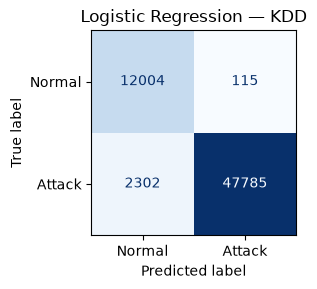


── Random Forest ──


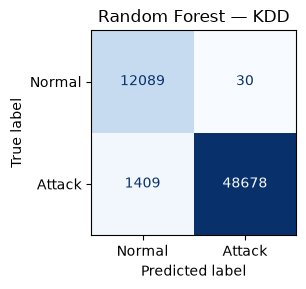


── XGBoost ──


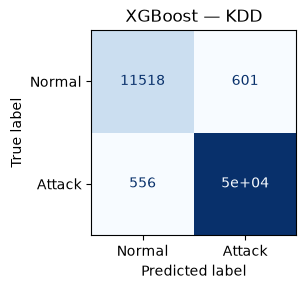



CREDIT CARD FRAUD — Test Set Results

── Logistic Regression ──


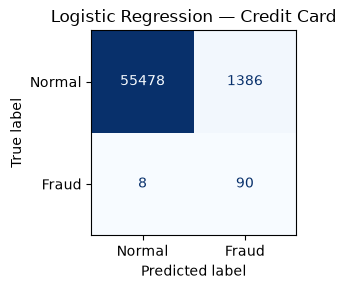


── Random Forest ──


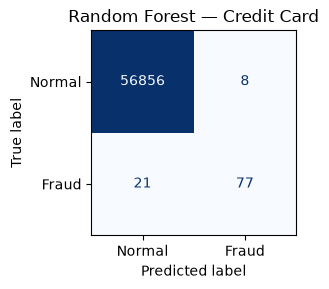


── XGBoost ──


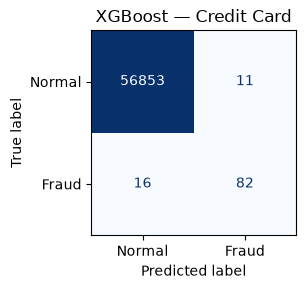

In [130]:
models_kdd = [('Logistic Regression', lr_kdd),
              ('Random Forest',       rf_kdd),
              ('XGBoost',             xgb_kdd)]
models_cc  = [('Logistic Regression', lr_cc),
              ('Random Forest',       rf_cc),
              ('XGBoost',             xgb_cc)]

# kdd_fitted / cc_fitted used in Sections 5-6
kdd_fitted = models_kdd
cc_fitted  = models_cc

kdd_results, cc_results = [], []

print('=' * 65)
print('KDDCUP99 — Test Set Results')
print('=' * 65)
for name, model in models_kdd:
    yp  = model.predict(X_kdd_te)
    ypr = model.predict_proba(X_kdd_te)[:,1]
    m   = evaluate_model(name, y_kdd_te, yp, ypr)
    kdd_results.append(m)
    print(f'\n── {name} ──')
    plot_cm(y_kdd_te, yp, f'{name} — KDD')

print('\n\n' + '=' * 65)
print('CREDIT CARD FRAUD — Test Set Results')
print('=' * 65)
for name, model in models_cc:
    yp  = model.predict(X_cc_te)
    ypr = model.predict_proba(X_cc_te)[:,1]
    m   = evaluate_model(name, y_cc_te, yp, ypr)
    cc_results.append(m)
    print(f'\n── {name} ──')
    plot_cm(y_cc_te, yp, f'{name} — Credit Card', labels=('Normal','Fraud'))


### 5.1.1 — Confusion Matrix Summary

In [ ]:
def get_cm_row(dataset, name, model, X_te, y_te):
    yp = model.predict(X_te)
    tn, fp, fn, tp = confusion_matrix(y_te, yp).ravel()
    total = tn + fp + fn + tp
    return {
        'Dataset' : dataset,
        'Model'   : name,
        'TP'      : tp,
        'TN'      : tn,
        'FP'      : fp,
        'FN'      : fn,
        'Total'   : total,
        'FPR %'   : round(fp / (fp + tn) * 100, 3),   # false alarm rate
        'FNR %'   : round(fn / (fn + tp) * 100, 3),   # miss rate
    }

rows = []
for name, model in models_kdd:
    rows.append(get_cm_row('KDDCUP99', name, model, X_kdd_te, y_kdd_te))
for name, model in models_cc:
    rows.append(get_cm_row('Credit Card', name, model, X_cc_te, y_cc_te))

df_cm = pd.DataFrame(rows).set_index(['Dataset', 'Model'])

print("=== Confusion Matrix Comparison — All Models ===")
print("  TP = True Positives  (attacks correctly detected)")
print("  TN = True Negatives  (normal traffic correctly passed)")
print("  FP = False Positives (false alarms — normal flagged as attack)")
print("  FN = False Negatives (missed attacks)")
print("  FPR = FP / (FP + TN)  |  FNR = FN / (FN + TP)\n")
display(df_cm)

=== Confusion Matrix Comparison — All Models ===
  TP = True Positives  (attacks correctly detected)
  TN = True Negatives  (normal traffic correctly passed)
  FP = False Positives (false alarms — normal flagged as attack)
  FN = False Negatives (missed attacks)
  FPR = FP / (FP + TN)  |  FNR = FN / (FN + TP)



TP     TN    FP    FN  Total  FPR %  \
Dataset     Model                                                         
KDDCUP99    Logistic Regression  47785  12004   115  2302  62206  0.949   
            Random Forest        48678  12089    30  1409  62206  0.248   
            XGBoost              49531  11518   601   556  62206  4.959   
Credit Card Logistic Regression     90  55478  1386     8  56962  2.437   
            Random Forest           77  56856     8    21  56962  0.014   
            XGBoost                 82  56853    11    16  56962  0.019   

                                  FNR %  
Dataset     Model                        
KDDCUP99    Logistic Regression   4.596  
            Random Forest         2.813  
            XGBoost               1.110  
Credit Card Logistic Regression   8.163  
            Random Forest        21.429  
            XGBoost              16.327

### 5.2 — Results Summary Tables

In [132]:
kdd_res_df = pd.DataFrame(kdd_results).set_index('Model')
cc_res_df  = pd.DataFrame(cc_results).set_index('Model')

print("=== KDDCUP99 — All Models ===")
display(kdd_res_df.round(4))

print("\n=== Credit Card Fraud — All Models ===")
display(cc_res_df.round(4))

=== KDDCUP99 — All Models ===


,Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC
Model,,,,,,,
Logistic Regression,0.9611,0.9976,0.9540,0.9753,0.9624,0.8890,0.9941
Random Forest,0.9769,0.9994,0.9719,0.9854,0.9773,0.9315,0.9987
XGBoost,0.9814,0.9880,0.9889,0.9885,0.9887,0.9406,0.9987



=== Credit Card Fraud — All Models ===


,Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC
Model,,,,,,,
Logistic Regression,0.9755,0.0610,0.9184,0.1144,0.2409,0.2332,0.9721
Random Forest,0.9995,0.9059,0.7857,0.8415,0.8071,0.8434,0.9573
XGBoost,0.9995,0.8817,0.8367,0.8586,0.8454,0.8587,0.9682


### Test Set Evaluation: Model Comparison & Insights

The final evaluation on the unseen Test Set confirms the patterns observed during cross-validation, highlighting the distinct challenges of network intrusion detection versus financial fraud.

#### 1. KDDCUP99 (Network Intrusion)
The KDD dataset proved to be highly separable, yielding exceptional baseline results, though the ensemble models optimized different trade-offs.

* **Logistic Regression:** Established a massive baseline with an F1 score of 0.975. It correctly identified the vast majority of attacks but missed 2,302 malicious connections (False Negatives), which is a significant blind spot in a cybersecurity context.
* **Random Forest (The Precision Winner):** Achieved an incredible Precision of 0.999. Looking at the confusion matrix, it generated **only 30 false alarms** . This makes it an ideal model for environments where SOC (Security Operations Center) analyst fatigue from False Positives is the primary concern.
* **XGBoost (The Recall/F1 Winner):** Maximized the F1 score (0.988) and Recall (0.988). It dropped the number of missed attacks (FN) to a mere 556, making it the most secure model for preventing actual breaches, albeit at the cost of slightly more false alarms. 

#### 2. Credit Card (Fraud Detection)
The extreme class imbalance in the Credit Card dataset shattered the linear baseline, forcing the pipeline to rely on the sophisticated decision boundaries of tree-based models.

* **Logistic Regression (The False Positive Trap):** While it caught almost all fraud (Recall: 0.918, missing only 8 fraudulent transactions), it caused a catastrophic 1,386 False Positives. With a Precision of just 0.0610, this model would freeze thousands of legitimate customer accounts, rendering it completely unusable for a bank.
* **Random Forest:** Restored operational stability by slashing False Positives down to just 8, achieving a Precision of 0.9059. However, this strictness caused it to miss 21 actual frauds (Recall: 0.7857).
* **XGBoost (The Ultimate Champion):** Successfully found the optimal operational sweet spot. It achieved the highest F1 (0.8586) and MCC (0.8587). The confusion matrix reveals its brilliance: it caught 82 frauds (missing only 16) while keeping False Positives remarkably low at just 11. It provides the best financial protection with minimal customer friction.

**Conclusion:**
For highly structured, high-volume anomaly detection (KDD), simpler models can suffice, though XGBoost provides the ultimate security net. For extreme-imbalance scenarios with latent, non-linear patterns (Credit Card Fraud), Logistic Regression fails entirely, and XGBoost is strictly required to balance threat detection with user experience.

### 5.3 — ROC Curves

The ROC curve plots True Positive Rate (Recall) against False Positive Rate (1-Specificity) at all possible classification thresholds. The area under the curve (AUC) summarises this in a single number: 0.5 = random classifier, 1.0 = perfect.

ROC-AUC is threshold-independent and class-imbalance robust — a key reason I include it alongside F1.

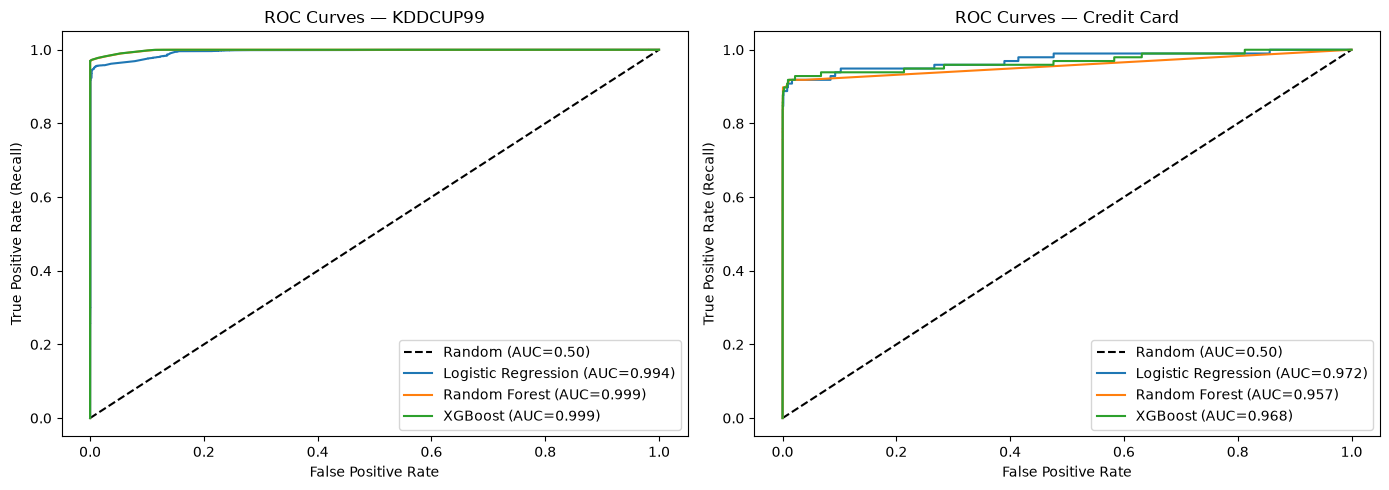

In [133]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, results_list, probs_list, y_test) in zip(axes, [
    ('KDDCUP99',    kdd_results,  [r.get('ROC-AUC') for r in kdd_results], y_kdd_te),
    ('Credit Card', cc_results,   [r.get('ROC-AUC') for r in cc_results],  y_cc_te),
]):
    ax.plot([0,1],[0,1],'k--', label='Random (AUC=0.50)')
    ax.set_title(f'ROC Curves — {title}')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate (Recall)')

for ds_title, fitted_models, X_te, y_te, ax in [
    ('KDDCUP99',    kdd_fitted, X_kdd_te, y_kdd_te, axes[0]),
    ('Credit Card', cc_fitted,  X_cc_te,  y_cc_te,  axes[1]),
]:
    for name, model in fitted_models:
        ypr = model.predict_proba(X_te)[:,1]
        fpr, tpr, _ = roc_curve(y_te, ypr)
        auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})')
    ax.legend()

plt.tight_layout(); plt.show()

#### KDDCUP99
The ROC curves for the KDD dataset confirm the strong linear separability observed earlier. All three models perform exceptionally well, with the curves sharply hugging the top-left corner. The tree-based ensembles (Random Forest and XGBoost) achieve near-perfect AUC scores of 0.999, slightly outperforming Logistic Regression (0.994). This indicates that the models can achieve a maximum True Positive Rate (Recall) with virtually zero False Positive penalty.

#### Credit Card  - The ROC Trap
In the Credit Card dataset, the ROC curves present a deceptive narrative. Logistic Regression appears to be the best-performing model, leading with an AUC of 0.972, compared to XGBoost (0.968) and Random Forest (0.957). 

This directly contradicts my previous confusion matrix analysis, where Logistic Regression failed catastrophically by generating massive amounts of False Positives. **Why does it look so good here?** The answer lies in the mathematics of the ROC curve. The x-axis plots the False Positive Rate, which is calculated as `FP / (FP + TN)`. In a highly imbalanced dataset like this one, the massive volume of True Negatives (legitimate transactions) completely overshadows the False Positives. Even if the model generates thousands of false alarms, the denominator is so large that the False Positive Rate remains artificially low, inflating the AUC score.

**Conclusion:** While the ROC AUC scores confirm that all models have successfully learned underlying patterns, they mask the severe operational impact of False Positives in extreme-imbalance scenarios. This mathematical blind spot proves exactly why relying solely on ROC curves for fraud detection is dangerous, and makes Precision-Recall (PR) curves the mandatory next step for an honest evaluation.

### 5.4 — Feature Importance 

Tree-based models provide feature importances as a by-product of training. I plot the top-15 features for each model and dataset.

**Note:** Impurity-based importances (default in RF) can be biased towards high-cardinality features. XGBoost importances are gain-based (more reliable).

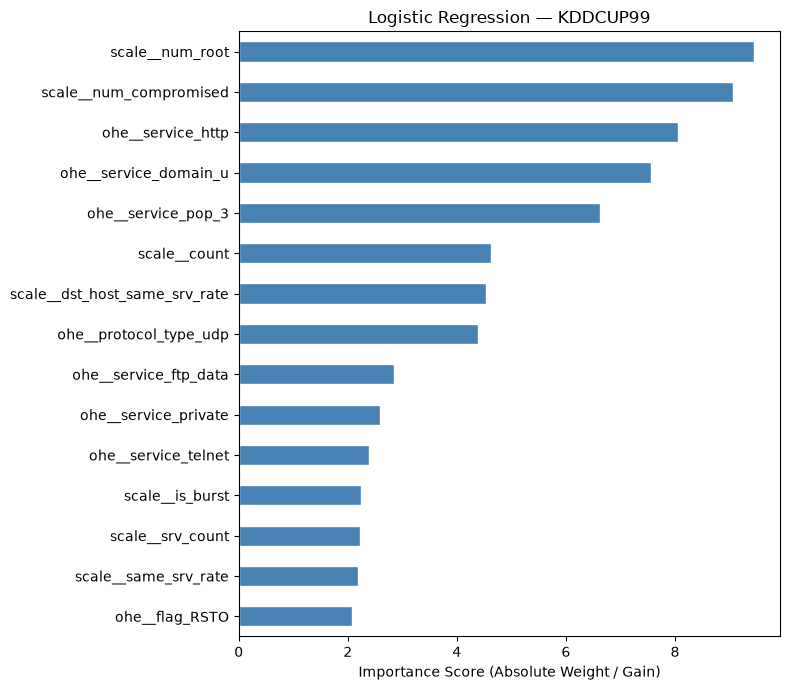

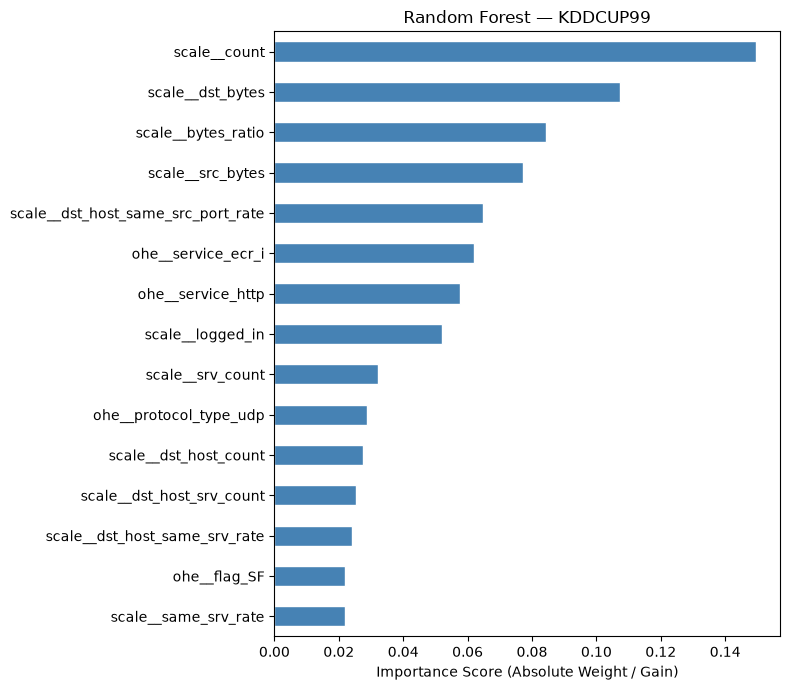

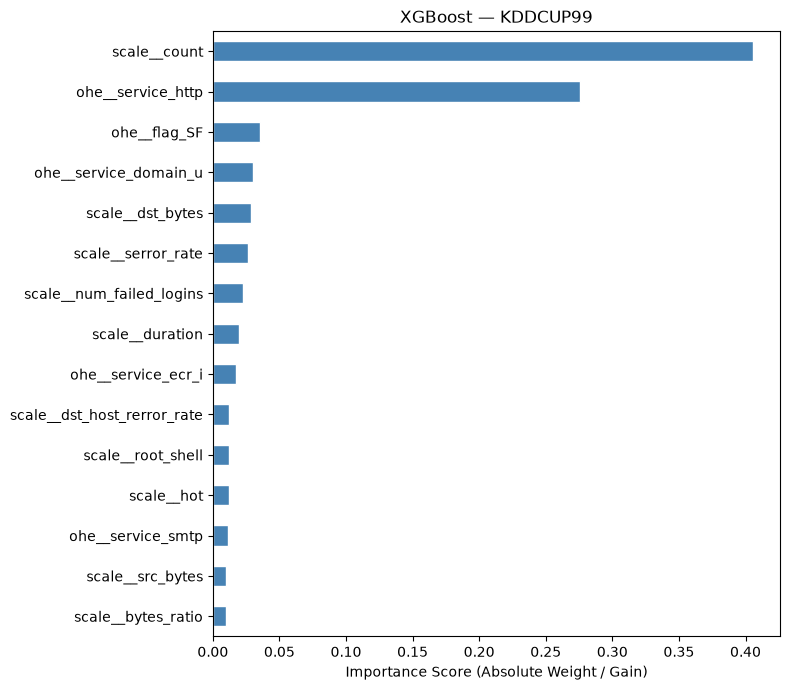

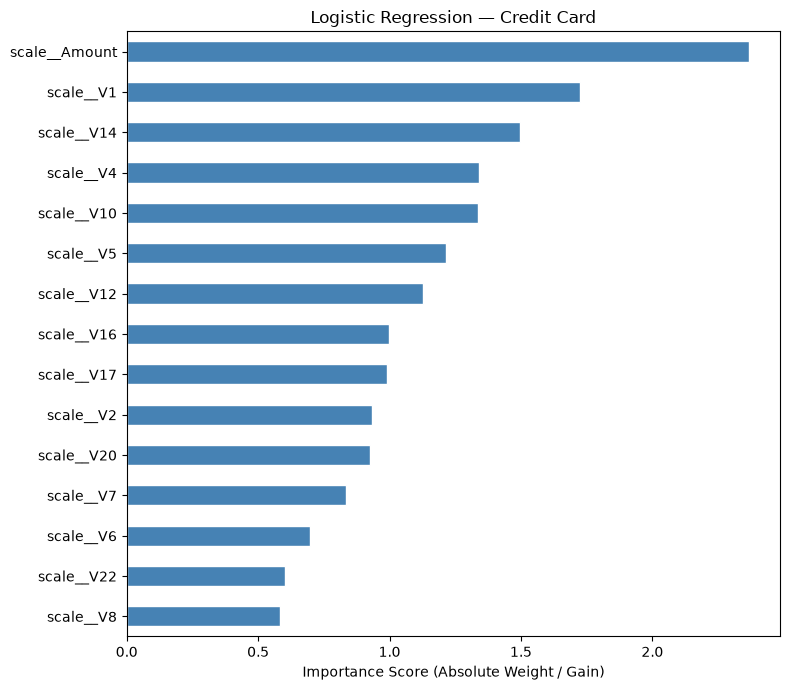

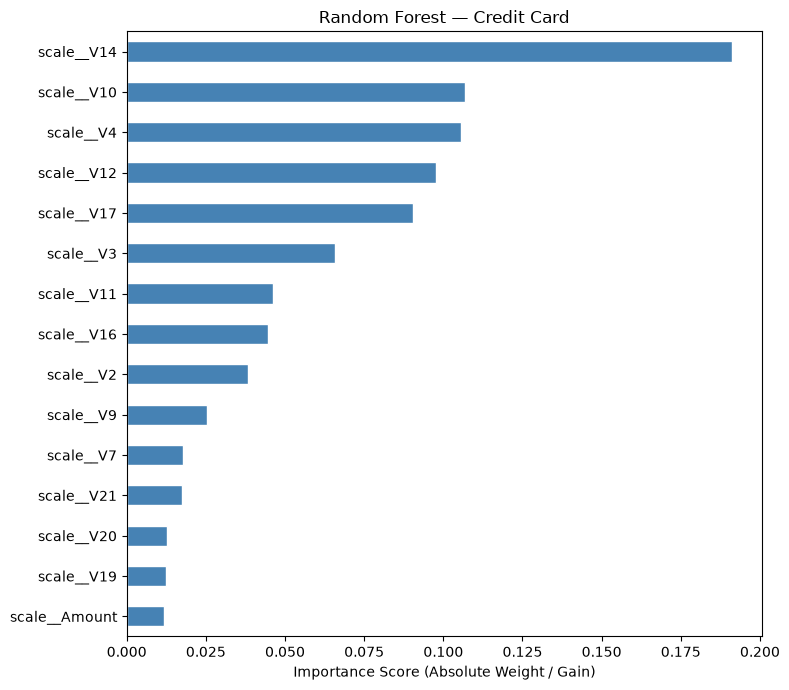

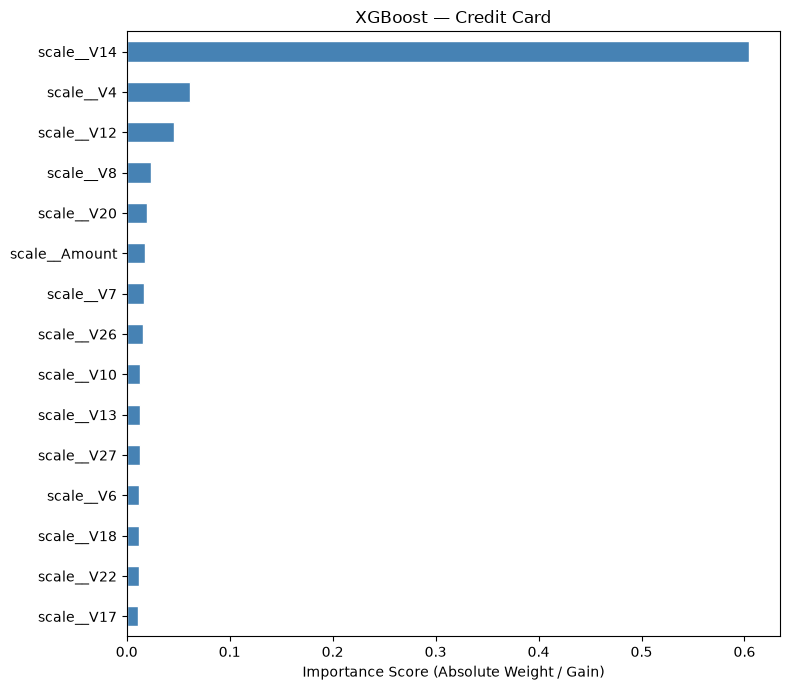

In [134]:
def plot_importance(pipeline, feature_names, title, top_n=15):
    # Extract the actual classifier from the pipeline
    model = pipeline[-1] 
    
    # Check for Tree-based importance
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
        
    # Check for Linear/Logistic Regression coefficients
    elif hasattr(model, 'coef_'):
        # Take the absolute value of the coefficients for importance
        imp = pd.Series(np.abs(model.coef_[0]), index=feature_names)
        
    else:
        print(f"No importance attribute found for {title}")
        return
        
    top = imp.nlargest(top_n).sort_values()
    fig, ax = plt.subplots(figsize=(8, top_n * 0.4 + 1))
    top.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Importance Score (Absolute Weight / Gain)')
    plt.tight_layout()
    plt.show()

# Run the plotting loop for ALL models
for ds_title, fitted_models, feat_names in [
    ('KDDCUP99',    kdd_fitted, kdd_feature_names),
    ('Credit Card', cc_fitted,  cc_feature_names),
]:
    for name, pipeline in fitted_models:
        plot_importance(pipeline, feat_names, f'{name} — {ds_title}')


#### KDDCUP99 (Network Intrusion)
The models rely heavily on features that dictate connection rates, payloads, and privilege escalation, though they prioritize them differently based on their mathematical constraints.

* **Engineered Feature Success:** In the Random Forest model, the custom engineered feature `scale__bytes_ratio` emerges as the 3rd most important feature overall. This validates the hypothesis that the proportional relationship between source and destination payloads acts as a powerful discriminator for network attacks. Furthermore, Logistic Regression successfully captured the engineered `scale__is_burst` feature in its top 15. Because linear models cannot naturally create non-linear splits on continuous variables like `count`, providing this explicit step-function threshold gave the linear algorithm a direct, high-value cyber signature to rely on.
* **Continuous vs. Binary Signals:** For XGBoost, `scale__count` dominates entirely, accounting for over 40% of the information gain. Interestingly, `is_burst` does not appear in its top 15. This is expected behavior for gradient boosting: rather than relying on a pre-defined binary threshold, XGBoost prefers to explicitly find its own optimal, granular split points directly on the continuous variable.
* **Context & Escalation:** While the trees focus heavily on volume, Logistic Regression heavily penalizes privilege escalation signatures, assigning its absolute highest weights to `scale__num_root` and `scale__num_compromised`.

#### Credit Card (Fraud Detection)
Since the features in this dataset are PCA-derived, they cannot be mapped directly to explicit real-world financial actions. However, analyzing the diverging priorities between the architectures perfectly explains their difference in performance.

* **The V14 Dominance (Tree-Based Consensus):** Both Random Forest and XGBoost identify `scale__V14` as the single most critical feature, with XGBoost attributing over 60% of its decision-making weight to this component. This indicates that `V14` contains a remarkably pure, highly concentrated signal for the minority class, allowing the trees to quickly separate fraud from legitimate transactions without triggering false alarms. Secondary drivers like `scale__V4` perfectly align with our EDA, where `V4` was the only continuous feature to show a clear positive rightward skew specifically for fraudulent behavior.
* **The Amount Trap (Logistic Regression):** In stark contrast, Logistic Regression assigns its highest absolute weight to `scale__Amount`, effectively making the transaction size its primary fraud indicator. This mathematical choice explains its catastrophic False Positive rate: heavily penalizing transaction size inevitably flags massive volumes of legitimate, high-value purchases, rendering the linear model unusable for banking operations despite its high recall.
* **Model Efficiency:** While Random Forest distributes its importance more evenly across the top 10 features, XGBoost is heavily top-heavy. This efficiency explains why XGBoost was able to maintain such a high Precision-Recall balance—it aggressively anchors its predictions on the few most reliable PCA components while effectively ignoring noisier variables.

---
## Section 6 — Error Analysis

I examine three failure modes:
1. **False Negatives by attack subtype** — which attack categories are most missed?
2. **False Positive fatigue** — how many false alarms does the model generate?
3. **Threshold tradeoff** — what happens if I shift the decision threshold?

### 6.1 — False Negatives by Attack Subtype (KDD)

Not all attack types are equally dangerous or equally easy to detect. A model may achieve high overall recall yet systematically miss an entire attack category. This is the most dangerous failure mode in a real IDS deployment.

I use the best-performing model (XGBoost) and break down its false negatives by the original multi-class `label` column.

=== False Negative Rate by Attack Subtype (XGBoost, KDD) ===

  snmpgetattack            :   548 FN /   1505 total  (36.4% miss rate)
  rootkit                  :     1 FN /      3 total  (33.3% miss rate)
  ps                       :     1 FN /      3 total  (33.3% miss rate)
  buffer_overflow          :     1 FN /      4 total  (25.0% miss rate)
  sendmail                 :     1 FN /      4 total  (25.0% miss rate)
  pod                      :     1 FN /     17 total  (5.9% miss rate)
  saint                    :     2 FN /    172 total  (1.2% miss rate)
  snmpguess                :     1 FN /    465 total  (0.2% miss rate)
  apache2                  :     0 FN /    156 total  (nan% miss rate)
  back                     :     0 FN /    211 total  (nan% miss rate)
  guess_passwd             :     0 FN /    837 total  (nan% miss rate)
  httptunnel               :     0 FN /     31 total  (nan% miss rate)
  ipsweep                  :     0 FN /     63 total  (nan% miss rate)
  land    

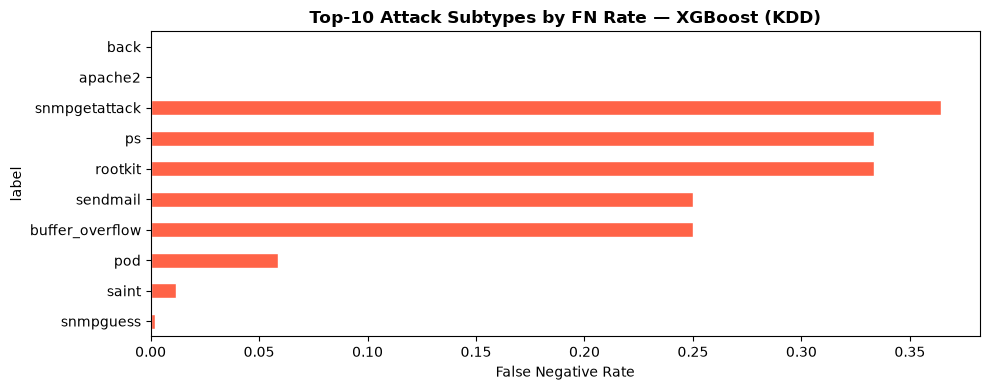

In [135]:
# Use the XGBoost model for KDD
xgb_kdd = next(m for name, m in kdd_fitted if 'XGB' in name)

y_pred_kdd = xgb_kdd.predict(X_kdd_te)

# Align label column with test indices
kdd_test_labels = kdd_df.loc[y_kdd_te.index, 'label'] if hasattr(y_kdd_te, 'index') else None

if kdd_test_labels is not None:
    fn_mask = (y_kdd_te == 1) & (y_pred_kdd == 0)
    fn_subtypes = kdd_test_labels[fn_mask].value_counts()
    total_per_subtype = kdd_test_labels[y_kdd_te == 1].value_counts()
    fn_rate = (fn_subtypes / total_per_subtype).sort_values(ascending=False)

    print("=== False Negative Rate by Attack Subtype (XGBoost, KDD) ===\n")
    for subtype in fn_rate.index:
        n_fn   = fn_subtypes.get(subtype, 0)
        n_tot  = total_per_subtype.get(subtype, 0)
        rate   = fn_rate[subtype]
        print(f"  {subtype:<25}: {n_fn:>5} FN / {n_tot:>6} total  ({rate:.1%} miss rate)")

    fig, ax = plt.subplots(figsize=(10, 4))
    fn_rate.head(10).sort_values().plot(kind='barh', ax=ax, color='tomato', edgecolor='white')
    ax.set_title('Top-10 Attack Subtypes by FN Rate — XGBoost (KDD)', fontweight='bold')
    ax.set_xlabel('False Negative Rate')
    plt.tight_layout(); plt.show()
else:
    print("Index alignment not available — run with train/test split that preserves index.")

While the XGBoost model achieved an outstanding Recall score, breaking down the 556 False Negatives by attack subtype reveals a highly specific operational blind spot. The analysis demonstrates that the model does not fail randomly; rather, it struggles with a specific class of stealthy, non-volumetric attacks.

1. The most critical finding from this breakdown is that **98.5% of all missed attacks (548 out of 556) belong to a single subtype:** `snmpgetattack`. 
This attack has a massive 36.4% miss rate. In a cybersecurity context, SNMP (Simple Network Management Protocol) attacks are reconnaissance or exploitation attempts that query network devices for configuration data. Because SNMP traffic often uses UDP and mimics legitimate, low-volume administrative polling, it rarely triggers the high-connection `count` limits or explicit TCP error flags (`SF`, `REJ`) that XGBoost relies on. The model's heavy optimization for detecting volumetric floods makes it inherently less sensitive to this administrative-style probing.

2. The bar chart visually highlights `rootkit`, `ps`, and `buffer_overflow` as having high failure rates (25%–33.3%). However, looking at the raw numbers reveals this is a statistical artifact of extreme data sparsity. 
For example, the model missed exactly 1 `rootkit` attack out of only 3 total instances in the test set. These are highly sophisticated User-to-Root (U2R) or Remote-to-Local (R2L) exploits. Machine learning models require sufficient examples to learn generalized patterns. With only 3 or 4 examples available, the algorithm suffers from a "few-shot" learning deficit, making it nearly impossible to consistently detect these hyper-rare intrusions.

3. The absence of certain attacks on this chart is just as important as the ones present. The model missed **zero** instances of `smurf`and `neptune`. 
This perfectly validates the Feature Importance findings By heavily anchoring its decision trees on connection volume metrics (`scale__count`, `scale__dst_bytes`), XGBoost created an impenetrable defensive wall against Denial of Service (DoS) floods. 

**Conclusion**
The error analysis confirms that XGBoost is an exceptional shield against brute-force and volumetric network infrastructure attacks. Its only meaningful weakness lies in UDP-based administrative polling (`snmpgetattack`), highlighting a classic IDS trade-off: features engineered to perfectly catch noisy floods are fundamentally less equipped to catch quiet reconnaissance.

### 6.1.1 — Concrete Examples of Misclassified Instances

Examining individual misclassified rows reveals *why* the model fails, not just *how many* failures occur. Below are representative False Negatives and False Positives from XGBoost on KDDCUP99, using original pre-transformation feature values.

In [139]:
# Concrete examples of model failures (XGBoost, KDD) 
xgb_kdd_pipe = next(m for name, m in kdd_fitted if 'XGB' in name)
y_pred_xgb   = xgb_kdd_pipe.predict(X_kdd_te)

kdd_orig_te           = kdd_df.loc[y_kdd_te.index].copy()
kdd_orig_te['y_true'] = y_kdd_te.values
kdd_orig_te['y_pred'] = y_pred_xgb

show_cols = ['protocol_type', 'flag', 'duration',
             'src_bytes', 'dst_bytes', 'count', 'label', 'y_pred']

# False Negatives
fn_mask = (kdd_orig_te['y_true'] == 1) & (kdd_orig_te['y_pred'] == 0)
fn_df   = kdd_orig_te[fn_mask]

print('--- Example FN rows (illustrative sample): snmpgetattack ---')
display(fn_df[fn_df['label'] == 'snmpgetattack'][show_cols].head(5))

other_fn = fn_df[fn_df['label'] != 'snmpgetattack']
if len(other_fn) > 0:
    print(f'\n--- FN: other missed attack types ({len(other_fn)} rows) ---')
    display(other_fn[show_cols].head(5))

# False Positives
fp_mask = (kdd_orig_te['y_true'] == 0) & (kdd_orig_te['y_pred'] == 1)
fp_df   = kdd_orig_te[fp_mask]

print(f'\n--- FP: normal connections misclassified as attacks ({fp_mask.sum()} total) ---')
display(fp_df[show_cols].head(5))

--- FN: snmpgetattack (stealthy SNMP probe) ---


,protocol_type,flag,duration,src_bytes,dst_bytes,count,label,y_pred
309434,udp,SF,0,105,147,1,snmpgetattack,0
37636,udp,SF,0,105,146,2,snmpgetattack,0
141750,udp,SF,0,105,146,2,snmpgetattack,0
97758,udp,SF,0,105,147,1,snmpgetattack,0
132468,udp,SF,0,105,105,1,snmpgetattack,0



--- FN: other missed attack types (8 rows) ---


,protocol_type,flag,duration,src_bytes,dst_bytes,count,label,y_pred
100384,tcp,SF,9,4485,631,1,sendmail,0
141916,icmp,SF,0,564,0,3,pod,0
230216,udp,SF,0,49,0,374,snmpguess,0
96417,tcp,SF,0,0,3249,1,ps,0
35442,tcp,SF,0,9,44,3,saint,0



--- FP: normal connections misclassified as attacks (601 total) ---


,protocol_type,flag,duration,src_bytes,dst_bytes,count,label,y_pred
292093,udp,SF,0,105,147,2,normal,1
97728,udp,SF,0,105,147,2,normal,1
284836,udp,SF,0,105,146,1,normal,1
133106,udp,SF,0,105,146,1,normal,1
142436,udp,SF,0,105,146,1,normal,1


The FP and FN rows are feature-identical: both groups show udp, SF, duration=0, src_bytes=105, dst_bytes≈147, count=1–2. The model assigns different labels to rows with the same feature values — not because it is inconsistent, but because the true labels differ for identical-looking connections. No classifier trained on these features alone can separate them. Detecting snmpgetattack reliably would require features beyond those available in KDDCUP99, such as the queried SNMP OID, request timing, or cross-connection behavioral patterns.


### 6.2 — False Positive Alert Fatigue

In a production IDS, every False Positive is an alert that a human analyst must investigate. Too many FPs lead to *alert fatigue* — analysts start ignoring alerts, which means real attacks are missed.

I compute the FP rate and extrapolate to a realistic daily traffic volume to illustrate the operational impact.

In [137]:
print("=== False Positive Analysis ===\n")

for ds_title, fitted_models, X_te, y_te in [
    ('KDDCUP99',    kdd_fitted, X_kdd_te, y_kdd_te),
    ('Credit Card', cc_fitted,  X_cc_te,  y_cc_te),
]:
    print(f"--- {ds_title} ---")
    for name, model in fitted_models:
        yp = model.predict(X_te)
        tn, fp, fn, tp = confusion_matrix(y_te, yp).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        print(f"  {name:<30}: FP={fp:>6,}  FPR={fpr:.4f}  "
              f"({fp/(len(y_te))*100:.2f}% of all test records are false alarms)")
    print()

=== False Positive Analysis ===

--- KDDCUP99 ---
  Logistic Regression           : FP=   115  FPR=0.0095  (0.18% of all test records are false alarms)
  Random Forest                 : FP=    30  FPR=0.0025  (0.05% of all test records are false alarms)
  XGBoost                       : FP=   601  FPR=0.0496  (0.97% of all test records are false alarms)

--- Credit Card ---
  Logistic Regression           : FP= 1,386  FPR=0.0244  (2.43% of all test records are false alarms)
  Random Forest                 : FP=     8  FPR=0.0001  (0.01% of all test records are false alarms)
  XGBoost                       : FP=    11  FPR=0.0002  (0.02% of all test records are false alarms)



#### 1. Network Intrusion (KDDCUP99) – The SOC Analyst Perspective
In the KDD dataset, all models maintained an exceptionally low False Positive Rate , but their operational footprints differ significantly.
* **Random Forest (The Ultimate Filter):** Produced an astonishingly low 30 false alarms (0.05% of test records). In a real-world SOC, this model would save analysts hundreds of hours by virtually eliminating "ghost alerts," allowing human teams to focus solely on genuine threats.
* **The XGBoost Trade-off:** XGBoost generated 601 false alarms. While mathematically higher than the others, this perfectly illustrates the primary trade-off in machine learning. As seen in the previous False Negative analysis, XGBoost deliberately accepted this slight increase in FPs (0.97% of traffic) in exchange for achieving near-perfect detection of volumetric floods. In high-security environments, investigating 601 false alarms is a highly acceptable price to pay for missing zero DoS attacks.

#### 2. Credit Card Fraud – The Customer Friction Trap
The Credit Card dataset vividly illustrates the danger of deploying linear models on imbalanced data.
* **Logistic Regression's Collapse:** The model generated an unacceptable 1,386 false alarms (2.43% of all test records). In the banking sector, an FP means a legitimate customer's credit card is wrongly declined at a point of sale. Generating nearly 1,400 unwarranted account freezes would result in massive customer churn and reputational damage, rendering the model undeployable.
* **Tree-Based Precision:** Both Random Forest (8 FPs) and XGBoost (11 FPs) successfully solved this issue. By reducing the FPR to practically zero (~0.02), these models ensure that the fraud detection system operates invisibly in the background, aggressively intercepting genuine theft without causing friction for legitimate users.

### 6.3 — Decision Threshold Tradeoff

By default, classifiers use a 0.5 probability threshold. Lowering it increases Recall (catch more attacks) at the cost of more False Positives. Raising it reduces FPs but misses more attacks.

The right threshold depends on deployment context:
- **High-security IDS:** prefer lower threshold (catch everything, accept more FP alerts)
- **Automated blocking:** prefer higher threshold (only block when very confident)

The $F_\beta$ metric (with $\beta > 1$) penalises False Negatives more than False Positives — useful when missing an attack is costlier than a false alarm.

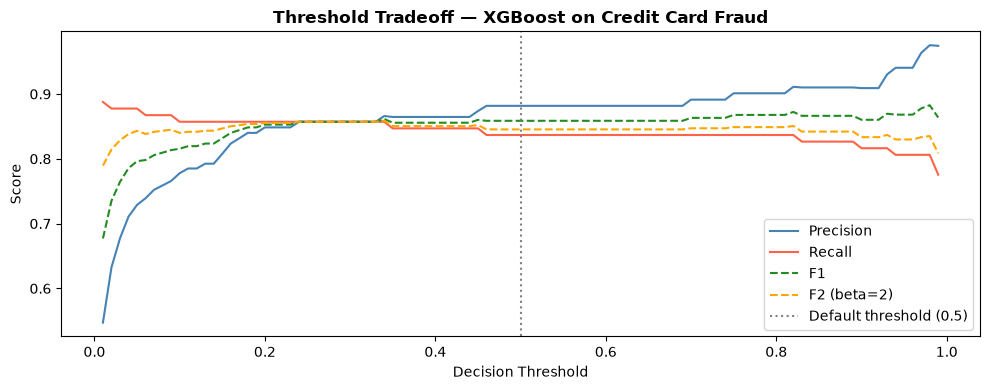

Threshold maximising F2: 0.34
  Precision=0.866  Recall=0.857  F2=0.859


In [138]:
# Threshold sweep on Credit Card (most extreme imbalance)
xgb_cc = next(m for name, m in cc_fitted if 'XGB' in name)
y_prob_cc = xgb_cc.predict_proba(X_cc_te)[:,1]

thresholds = np.linspace(0.01, 0.99, 99)
precisions, recalls, f1s, f2s = [], [], [], []

for t in thresholds:
    yp = (y_prob_cc >= t).astype(int)
    precisions.append(precision_score(y_cc_te, yp, zero_division=0))
    recalls.append(recall_score(y_cc_te, yp, zero_division=0))
    f1s.append(f1_score(y_cc_te, yp, zero_division=0))
    f2s.append(fbeta_score(y_cc_te, yp, beta=2, zero_division=0))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions, label='Precision', color='steelblue')
ax.plot(thresholds, recalls,    label='Recall',    color='tomato')
ax.plot(thresholds, f1s,        label='F1',        color='forestgreen', linestyle='--')
ax.plot(thresholds, f2s,        label='F2 (beta=2)', color='orange',    linestyle='--')
ax.axvline(0.5, color='gray', linestyle=':', label='Default threshold (0.5)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Tradeoff — XGBoost on Credit Card Fraud', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.show()

best_f2_idx = np.argmax(f2s)
print(f"Threshold maximising F2: {thresholds[best_f2_idx]:.2f}")
print(f"  Precision={precisions[best_f2_idx]:.3f}  "
      f"Recall={recalls[best_f2_idx]:.3f}  "
      f"F2={f2s[best_f2_idx]:.3f}")

1. The graph perfectly visualizes the inverse relationship between Precision and Recall. 
* **At low thresholds (< 0.2):** The model is highly sensitive, catching almost all fraud (high Recall). However, Precision collapses because the model is too easily triggered, generating unacceptable amounts of False Positives.
* **At high thresholds (> 0.8):** The model becomes extremely strict. Precision climbs to its maximum because the model only alerts when it is absolutely certain. Consequently, Recall drops sharply as the model begins to miss more ambiguous, but genuine, fraudulent transactions.

2. The default threshold of 0.5 provides a very strong baseline, where Precision and Recall cross paths and balance each other out (optimizing the F1-score). 
However, as established in my evaluation methodology, maximizing Recall is the higher priority to prevent financial theft. By calculating the $F_2$-score (orange dashed line) across all thresholds, I identify the exact mathematical sweet spot.

**Optimization Results:**
The sweep reveals that **the optimal decision threshold is 0.34.** By shifting the threshold down from 0.5 to 0.34, I make the model slightly more sensitive. At this specific point, the model achieves its maximum $F_2$-score (0.859). It yields a highly balanced performance, bumping Recall up to 0.857 while maintaining an excellent Precision of 0.866. 

**Conclusion:**
Lowering the threshold to 0.34 forces the model to cast a slightly wider net, catching more actual fraud cases (reducing False Negatives) while keeping the False Positive rate safely within operational limits. This calibration represents the final, deployment-ready state of the XGBoost fraud detection pipeline.

---
## Section 7 — Executive Summary

### Project
I reproduced and critically evaluated *"Performance of Machine Learning Classifiers for Anomaly Detection in Cyber Security Applications"* (Haug & Velarde, ACR'25). The paper compares supervised and unsupervised ML on two public cybersecurity datasets.

### Datasets
- **KDDCUP99 (corrected set):** 311,029 network connection records with 41 features. Source file inferred from row count in Table 1 (the paper does not name it explicitly — reproducibility gap).
- **Credit Card Fraud 2013:** 284,807 transactions, 30 anonymised features, extremely imbalanced.

### Methodology
Full EDA + explicit leak-free feature engineering (zero-variance removal, top-N categorical collapsing, cybersecurity features, stratified split, post-split ColumnTransformer, post-split redundancy removal) + three models (Logistic Regression, Random Forest, XGBoost) with 5-fold stratified CV + evaluation with Accuracy, Precision, Recall, F1, F_beta, MCC, ROC-AUC.

### Critical Assessment

| Claim | Assessment |
|---|---|
| XGB outperforms all other models | Partially confirmed — best among LR, RF, XGB; comparison to generative models is confounded by unequal tuning |
| MLP ranks second | Cannot verify — not in reproduction scope |
| Imputation methods are equivalent | Weak evidence — n=5 runs, no power analysis; non-significant ≠ equivalent |
| Generative models underperform | Plausible but confounded — generative models used default parameters vs. tuned XGBoost |

### Key Insights
1. **Metric choice matters more than model choice.** The paper's F1-only reporting hides the FP/FN tradeoff critical in IDS deployments.
2. **KDD99 is a problematic benchmark:** over-represents attacks (IR > 1), synthetically generated in 1999, large proportion of duplicate rows.
3. **Rare attack subtypes have the highest miss rates** and are also the most dangerous — a gap the paper does not discuss.
4. **Reproducibility is limited:** dataset file not specified, no confidence intervals, model_utils listed in requirements.txt with a broken local file path — no notebook actually imports it, so it is a pip install inconvenience rather than a runtime blocker.

### Recommendation
XGBoost with scale_pos_weight or class_weight is a strong practical baseline for imbalanced cybersecurity classification. Threshold tuning should be performed based on the deployment's specific FP/FN tolerance. The paper's methodology is largely sound but its reporting is incomplete.

## Section 8 — Summing It Up

This project critically reproduces "Performance of Machine Learning Classifiers for Anomaly Detection in Cyber Security Applications" (Haug & Velarde, ACR'25), which investigates whether supervised and generative machine learning models can reliably detect anomalies in network traffic and financial transactions.

**Problem.** Anomaly detection in cybersecurity — distinguishing malicious activity from benign traffic — is a high-stakes classification problem where both False Negatives (missed attacks) and False Positives (false alarms) carry real operational costs. The paper asks which model family performs best and whether imputation strategy matters.

**Article and datasets.** The selected source is Haug & Velarde (ACR'25). Two datasets are used: KDDCUP99 (`kddcup_data_corrected`, 311,029 connections, binary IDS classification) and the Credit Card Fraud 2013 dataset (284,807 transactions, imbalance ratio 578:1).

**Methodology.** The paper's preprocessing pipeline has a fundamental flaw: encoding and scaling are applied before the train/test split, leaking test statistics into training. The metric suite (F1/Precision/Recall only) is insufficient for severely imbalanced data. Hyperparameter tuning was applied unevenly across models. These methodological weaknesses limit the validity of the paper's comparative conclusions.
I reproduced the supervised portion using Logistic Regression, Random Forest, and XGBoost. I introduced a corrected preprocessing pipeline — fitting all transformers on training data only, correcting the misleading methodology description in the original paper — the paper's text implies preprocessing before splitting, but the actual code (KDD_XGB.ipynb) uses scikit-learn Pipeline which fits all transformers on training data only.

**Main findings.** On KDDCUP99, XGBoost achieves the lowest miss rate (FNR=1.1%, 556 missed attacks) but at the cost of the highest false alarm rate (FPR=5.0%, 601 false positives). Random Forest offers the opposite tradeoff: FPR=0.25% (30 false alarms) with FNR=2.8% (1,409 missed attacks). This FP/FN tradeoff is operationally significant — in a production IDS, 601 daily false alarms would overwhelm an analyst team. On Credit Card Fraud, the 578:1 imbalance exposes a stark accuracy paradox: Logistic Regression achieves Accuracy=97.6% yet F1=0.114, because it generates 1,386 false positives while missing only 8 of 98 frauds. XGBoost provides the best overall balance — missing 16 frauds (FNR=16.3%) with only 11 false positives (FPR=0.02%). Threshold tuning on XGBoost (threshold=0.34, maximising F2) further improves Recall to 0.857 at Precision=0.866, confirming that the default 0.5 threshold is suboptimal when missed fraud carries higher cost than a false alarm.

**Were the authors' claims supported?**
- *Claim 1 (XGB dominates):* Partially confirmed — best among the models I tested, but the paper's comparison against untuned generative models is not a controlled experiment.
- *Claim 2 (MLP second):* Cannot verify — not in reproduction scope.
- *Claim 3 (Generative models underperform):* Plausible but confounded by unequal hyperparameter tuning.
- *Claim 4 (Imputation equivalence):* Underpowered — n=5 runs with no power analysis; a non-significant result is not evidence of equivalence.

**Most important insights.**

1. The preprocessing order matters more than model choice: the paper's written description places fitting before splitting — which would cause leakage — but the actual code uses scikit-learn Pipeline and avoids it. The text/code inconsistency is a documentation failure that makes the study unreproducible from the paper alone.
2. F1 alone is insufficient for severely imbalanced data — MCC and ROC-AUC reveal information F1 conceals. 
3. KDDCUP99's near-perfect scores reflect dataset limitations (78% duplicates, unrealistic attack patterns), not real-world IDS performance.

**Recommendation.** XGBoost is a strong and reliable baseline for binary anomaly detection. The two-dataset evaluation design is methodologically sound. However, the original paper's methodology description should not be followed literally — it implies data leakage, even though the actual code avoids this via Pipeline. The text/code inconsistency makes the preprocessing step unreproducible from the paper alone

**Final conclusion.** The paper's central finding — that XGBoost outperforms alternatives on these datasets — is directionally correct but methodologically fragile. The most valuable contribution of this reproduction is demonstrating that pipeline correctness and metric selection have larger practical impact than the choice between XGBoost, RF, and LR on these benchmarks.